# 08 — Results Visualisation

**DATSCI7030 · Causal Event-Driven Market Impact Modelling**
Author: Ibrahim Haroun · LJMU 2025–2026 · Version 2.0
Updated 2026-07-06 (Results Visualisation Freeze, RVF v1.0): Figures 08c/08d have been rebuilt to read exclusively from the canonical, frozen pipeline (`feature_matrix.parquet`, `reports/model_comparison/`, `reports/baseline/`) instead of the legacy `model_features.parquet`/`model_comparison.parquet`/`test_predictions.parquet`/`shap_values.parquet`/`evaluation_summary.parquet`. All four figures now trace only to frozen, MCP v1.0-verified artefacts — no legacy pipeline dependency remains in this notebook. See `10_decision_log.md` (2026-07-06, "Results Visualisation Freeze v1.0").

---

## Purpose

Produce integrated, publication-style figures narrating the full pipeline for the dissertation, sourced exclusively from the frozen canonical artefacts.

1. **Figure 08a — Event Landscape** — event volume, type distribution, sentiment over time, president breakdown
2. **Figure 08b — Causal Evidence** — CAR distributions, DoWhy estimates with CI, sentiment-CAR scatter, regime interaction
3. **Figure 08c — Predictive Pipeline** — feature importance by category (FES v1.0), 4-model comparison (incl. `Baseline_LASSO`), SHAP top drivers, RQ3 verdict
4. **Figure 08d — Full-Period Dashboard** — integrated test-period timeline: SPY + VIX + events + representative model signal + illustrative cumulative return

## Inputs

- `data/processed/{events_tagged, daily_sentiment, car_results, causal_estimates, feature_matrix}.parquet`
- `reports/model_comparison/{model_comparison, feature_importance, event_model_predictions, shap_values_event_lasso, shap_values_xgboost, shap_values_lightgbm, statistical_tests.json}`
- `reports/baseline/baseline_predictions.parquet`

No legacy artefact (`model_features.parquet`, `feature_metadata.parquet`, `test_predictions.parquet`, `shap_values.parquet`, `model_comparison.parquet` in `data/processed/`, `evaluation_summary.parquet`, `models/model_metadata.json`) is read anywhere in this notebook.

## Outputs

`reports/figures/08a_event_landscape.png` … `08d_full_dashboard.png` (300 dpi).

## Research Questions Supported

RQ1 (`08a`, `08b`), RQ2 (`08c` — feature importance/SHAP), RQ3 (`08c`, `08d` — 4-model comparison and RQ3 verdict, explicitly stating H0(3) not rejected).

## Pipeline Position

`07_model_evaluation.ipynb` → **`08_results_visualisation.ipynb`** → Dissertation.

## Scope — this notebook DOES

- Assemble multi-panel dissertation figures from already-computed, frozen upstream outputs
- State the RQ3 verdict (H0(3) not rejected) explicitly on every figure/panel that compares models, so no figure can be read as claiming a model "wins"

## Scope — this notebook does NOT

- Perform any new analysis, statistical test, or model training
- Change any model conclusion, frozen dataset, or model artefact
- Claim any event-enhanced model beats `Baseline_LASSO` — none does, at the Bonferroni-corrected threshold

**Inputs:** see above
**Outputs:** `08a`–`08d` PNG figures (300 dpi, dissertation-ready)

In [1]:
import os, sys, warnings, pickle, json
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
from matplotlib.patches import Patch, FancyArrowPatch
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT   = Path('..').resolve()
PROC   = ROOT / 'data' / 'processed'
MODELS = ROOT / 'models'
FIGS   = ROOT / 'reports' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

# ── Publication plot style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':          150,
    'savefig.dpi':         300,       # dissertation quality
    'figure.facecolor':    'white',
    'axes.facecolor':      'white',
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.grid':           True,
    'grid.alpha':          0.25,
    'grid.linestyle':      '--',
    'font.family':         'sans-serif',
    'font.size':           10,
    'axes.titlesize':      11,
    'axes.labelsize':      10,
    'legend.fontsize':     8,
    'xtick.labelsize':     8,
    'ytick.labelsize':     8,
})

# ── Colour palette (consistent across all figures) ────────────────────────────
C = {
    'monetary':    '#1f4e79',
    'geopolitical':'#c55a11',
    'regulatory':  '#70ad47',
    'trade':       '#7030a0',
    'energy':      '#d4a017',
    'other':       '#95a5a6',
    'positive':    '#27ae60',
    'negative':    '#e74c3c',
    'neutral':     '#95a5a6',
    'spy':         '#2c3e50',
    'vix':         '#e74c3c',
    'lasso':       '#1f4e79',
    'xgb':         '#c55a11',
    'lgb':         '#70ad47',
    'strategy':    '#7030a0',
    'bh':          '#95a5a6',
}

EVENT_ORDER = ['monetary','geopolitical','regulatory','trade','energy']

print('✓ Imports complete — publication style active')

✓ Imports complete — publication style active


---
## Section 1 — Load All Data

In [2]:
# ── Phase 3 outputs (current, unchanged) ───────────────────────────────────────
events_df   = pd.read_parquet(PROC / 'events_tagged.parquet')
sent_df     = pd.read_parquet(PROC / 'daily_sentiment.parquet')
events_df['date'] = pd.to_datetime(events_df['date'])
sent_df['date']   = pd.to_datetime(sent_df['date'])

# ── Phase 4 outputs (current, unchanged) ───────────────────────────────────────
car_df     = pd.read_parquet(PROC / 'car_results.parquet')
causal_df  = pd.read_parquet(PROC / 'causal_estimates.parquet')
car_df['date'] = pd.to_datetime(car_df['date'])

# ── Canonical feature/model pipeline (FES v1.0 / MCP v1.0) ─────────────────────
# Rebuilt 2026-07-06 (Results Visualisation Freeze, RVF v1.0). Replaces the
# legacy model_features.parquet / feature_metadata.parquet / test_predictions.parquet /
# shap_values.parquet / model_comparison.parquet / evaluation_summary.parquet /
# models/model_metadata.json previously read here -- see 10_decision_log.md.
MC   = ROOT / 'reports' / 'model_comparison'
BASE = ROOT / 'reports' / 'baseline'

feat_df = pd.read_parquet(PROC / 'feature_matrix.parquet')   # FES v1.0 -- 95 features, 2,511 rows
feat_df['date'] = pd.to_datetime(feat_df['date'])

comp_df            = pd.read_parquet(MC / 'model_comparison.parquet')          # Baseline_LASSO/Event_LASSO/XGBoost/LightGBM x train/test
feat_imp_df        = pd.read_parquet(MC / 'feature_importance.parquet')        # 95 features x importance/category
event_preds_df     = pd.read_parquet(MC / 'event_model_predictions.parquet')   # date, split, actual, {model}_pred
baseline_preds_df  = pd.read_parquet(BASE / 'baseline_predictions.parquet')
event_preds_df['date']    = pd.to_datetime(event_preds_df['date'])
baseline_preds_df['date'] = pd.to_datetime(baseline_preds_df['date'])

shap_dfs = {
    'Event_LASSO': pd.read_parquet(MC / 'shap_values_event_lasso.parquet'),
    'XGBoost':     pd.read_parquet(MC / 'shap_values_xgboost.parquet'),
    'LightGBM':    pd.read_parquet(MC / 'shap_values_lightgbm.parquet'),
}

with open(MC / 'statistical_tests.json') as f:
    stats_tests = json.load(f)

# Train/test split boundary under FES v1.0 (see feature_profile.json)
TRAIN_CUT = feat_df[feat_df['split'] == 'train']['date'].max()

# Representative event-enhanced model for the single-model panels below.
# Chosen as Event_LASSO: smallest Diebold-Mariano p-value and largest RMSE
# improvement of the three event-enhanced models (statistical_tests.json) --
# i.e. the model numerically closest to Baseline_LASSO, NOT a declared winner:
# none of the three clears the Bonferroni-corrected threshold (H0(3) not rejected).
REPRESENTATIVE_MODEL = 'Event_LASSO'

test_preds = event_preds_df[event_preds_df['split'] == 'test'].sort_values('date').reset_index(drop=True)
y_true     = test_preds['actual'].values
y_rep      = test_preds[f'{REPRESENTATIVE_MODEL}_pred'].values
rep_dates  = test_preds['date'].values

rq3_verdict = stats_tests['results_by_model']['Event_LASSO']['comparison_vs_baseline']['bonferroni_verdict']['verdict']

print(f'Events           : {len(events_df):,}')
print(f'CAR records      : {len(car_df):,}')
print(f'Feature matrix   : {feat_df.shape[0]:,} rows x {feat_df.shape[1]} cols (FES v1.0)')
print(f'Test days        : {len(test_preds):,}')
print(f'Representative event-enhanced model (illustration only): {REPRESENTATIVE_MODEL}')
print(f'RQ3 verdict (all 3 event-enhanced models): {rq3_verdict}')
print('✓ All canonical data loaded -- no legacy pipeline files read')

Events           : 1,005
CAR records      : 264
Feature matrix   : 2,477 rows x 98 cols (FES v1.0)
Test days        : 750
Representative event-enhanced model (illustration only): Event_LASSO
RQ3 verdict (all 3 event-enhanced models): Does not beat baseline (neither leg significant, Bonferroni-corrected)
✓ All canonical data loaded -- no legacy pipeline files read


---
## Figure 08a — Event Landscape (2015–2025)

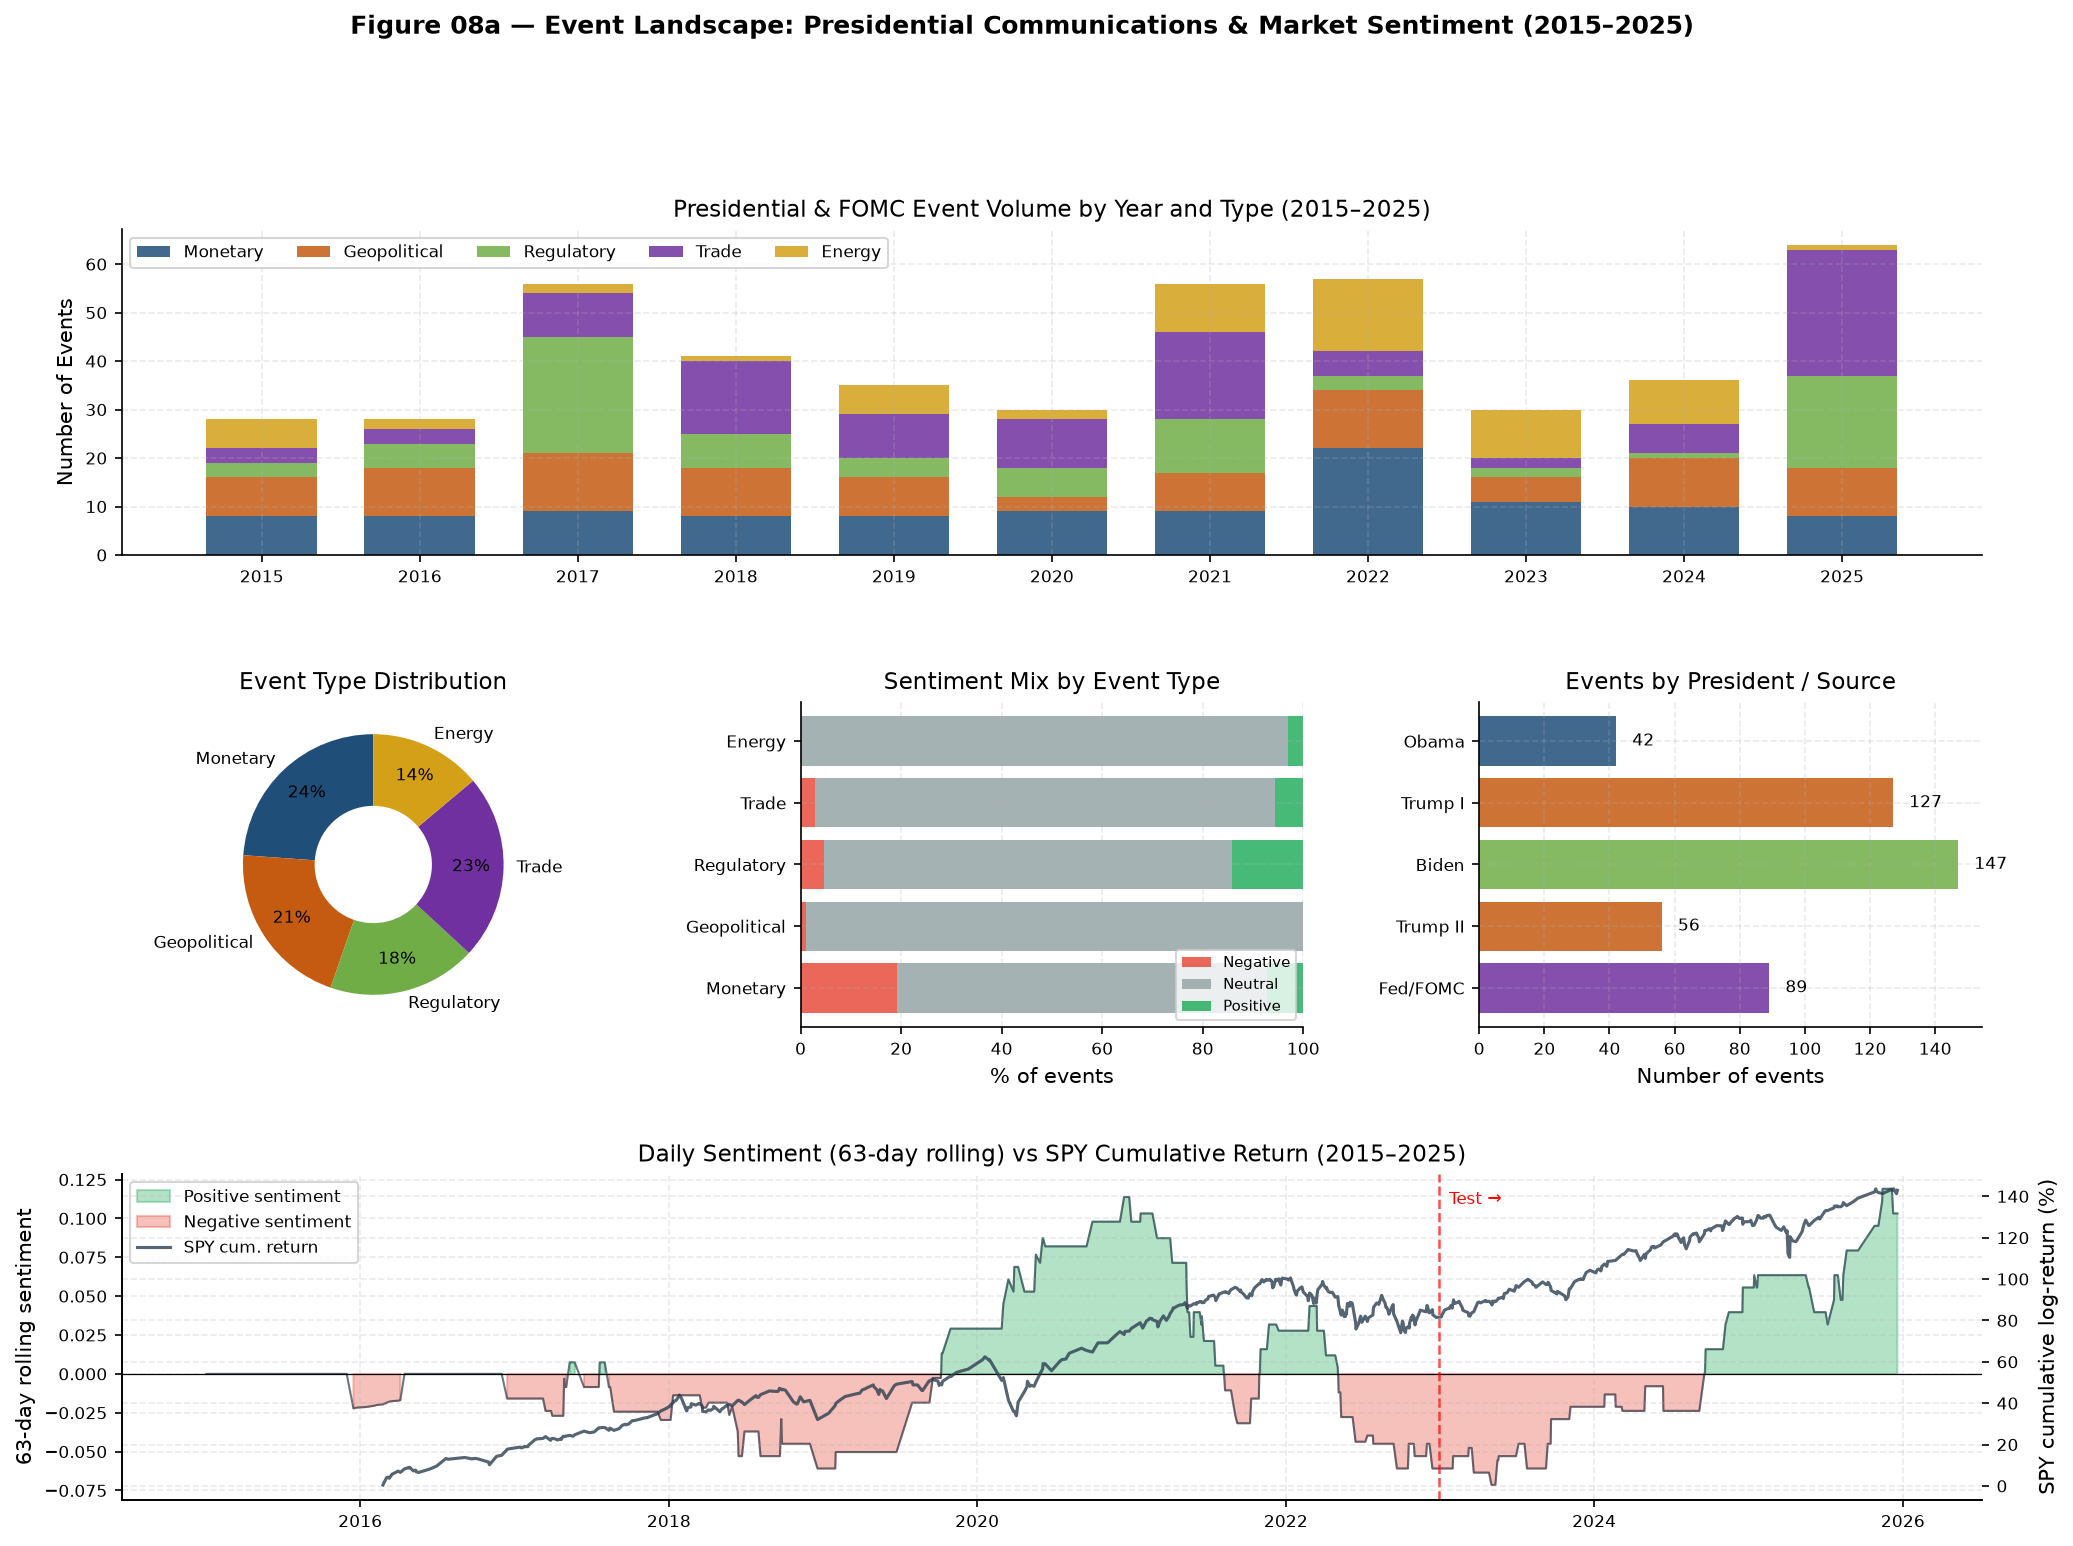

✓ Saved 08a_event_landscape.png


In [3]:
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1 (top, full width): Event volume over time by type ─────────────────
ax1 = fig.add_subplot(gs[0, :])
yearly = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    .assign(year=events_df['date'].dt.year)
    .groupby(['year','event_type'])
    .size().unstack(fill_value=0)
)
# Reorder columns
yearly = yearly.reindex(columns=[e for e in EVENT_ORDER if e in yearly.columns])
bottom = np.zeros(len(yearly))
for col in yearly.columns:
    ax1.bar(yearly.index, yearly[col], bottom=bottom,
            color=C[col], alpha=0.85, label=col.capitalize(), width=0.7)
    bottom += yearly[col].values
ax1.set_ylabel('Number of Events')
ax1.set_title('Presidential & FOMC Event Volume by Year and Type (2015–2025)')
ax1.legend(loc='upper left', ncol=5, fontsize=8)
ax1.set_xticks(yearly.index)

# ── Panel 2 (mid-left): Event type distribution (donut) ──────────────────────
ax2 = fig.add_subplot(gs[1, 0])
type_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    ['event_type'].value_counts().reindex(EVENT_ORDER).fillna(0)
)
wedges, texts, autotexts = ax2.pie(
    type_counts.values,
    labels=[t.capitalize() for t in type_counts.index],
    colors=[C[t] for t in type_counts.index],
    autopct='%1.0f%%', startangle=90,
    pctdistance=0.75, wedgeprops=dict(width=0.55)
)
for at in autotexts: at.set_fontsize(8)
ax2.set_title('Event Type Distribution')

# ── Panel 3 (mid-centre): Sentiment distribution by event type ───────────────
ax3 = fig.add_subplot(gs[1, 1])
sent_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    .groupby(['event_type','sentiment_label'])
    .size().unstack(fill_value=0)
)
sent_counts = sent_counts.reindex(index=EVENT_ORDER)
sent_pct = sent_counts.div(sent_counts.sum(axis=1), axis=0) * 100
bottom_s = np.zeros(len(sent_pct))
for sent_label, col in [('negative', C['negative']), ('neutral', C['neutral']), ('positive', C['positive'])]:
    if sent_label in sent_pct.columns:
        ax3.barh([e.capitalize() for e in sent_pct.index],
                 sent_pct[sent_label], left=bottom_s,
                 color=col, alpha=0.85, label=sent_label.capitalize())
        bottom_s += sent_pct[sent_label].values
ax3.set_xlabel('% of events')
ax3.set_title('Sentiment Mix by Event Type')
ax3.legend(loc='lower right', fontsize=7)
ax3.set_xlim(0, 100)

# ── Panel 4 (mid-right): Events by president ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
pres_short = {
    'Barack Obama':              'Obama',
    'Donald J. Trump (1st Term)':'Trump I',
    'Joseph R. Biden, Jr.':      'Biden',
    'Donald J. Trump (2nd Term)':'Trump II',
    'Federal Reserve':           'Fed/FOMC',
}
pres_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    ['president'].map(pres_short).value_counts()
)
pres_order = ['Obama','Trump I','Biden','Trump II','Fed/FOMC']
pres_counts = pres_counts.reindex([p for p in pres_order if p in pres_counts.index])
PALETTE_PRES = ['#1f4e79','#c55a11','#70ad47','#c55a11','#7030a0']
ax4.barh(pres_counts.index[::-1], pres_counts.values[::-1],
         color=PALETTE_PRES[:len(pres_counts)][::-1],
         alpha=0.85)
for i, val in enumerate(pres_counts.values[::-1]):
    ax4.text(val + 5, i, str(val), va='center', fontsize=8)
ax4.set_xlabel('Number of events')
ax4.set_title('Events by President / Source')

# ── Panel 5 (bottom, full width): Rolling daily sentiment vs SPY ─────────────
ax5 = fig.add_subplot(gs[2, :])
daily_overall = sent_df.set_index('date')['overall_mean_sentiment'].fillna(0)
rolling_sent  = daily_overall.rolling(63, min_periods=1).mean()
# SPY log-returns cumulative
spy_ret = feat_df.set_index('date')['log_return']
spy_cum = (spy_ret.cumsum() * 100).reindex(rolling_sent.index, method='ffill')

ax5b = ax5.twinx()
ax5.fill_between(rolling_sent.index, rolling_sent, 0,
                 where=rolling_sent >= 0, alpha=0.35, color=C['positive'], label='Positive sentiment')
ax5.fill_between(rolling_sent.index, rolling_sent, 0,
                 where=rolling_sent < 0, alpha=0.35, color=C['negative'], label='Negative sentiment')
ax5.plot(rolling_sent.index, rolling_sent, linewidth=1, color='#2c3e50', alpha=0.7)
ax5b.plot(spy_cum.index, spy_cum.values, color=C['spy'], linewidth=1.5, alpha=0.8, label='SPY cum. return')
ax5.set_ylabel('63-day rolling sentiment')
ax5b.set_ylabel('SPY cumulative log-return (%)')
ax5.set_title('Daily Sentiment (63-day rolling) vs SPY Cumulative Return (2015–2025)')
lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5b.get_legend_handles_labels()
ax5.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
ax5.axhline(0, color='black', linewidth=0.6)
# Mark train/test split
ax5.axvline(pd.Timestamp(TRAIN_CUT), color='red', linewidth=1.2,
            linestyle='--', alpha=0.7, label='Train/test split')
ax5.text(pd.Timestamp(TRAIN_CUT), ax5.get_ylim()[1] * 0.85, '  Test →',
         color='red', fontsize=8)

plt.suptitle('Figure 08a — Event Landscape: Presidential Communications & Market Sentiment (2015–2025)',
             fontsize=12, fontweight='bold', y=1.01)
plt.savefig(FIGS / '08a_event_landscape.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved 08a_event_landscape.png')

---
## Figure 08b — Causal Evidence

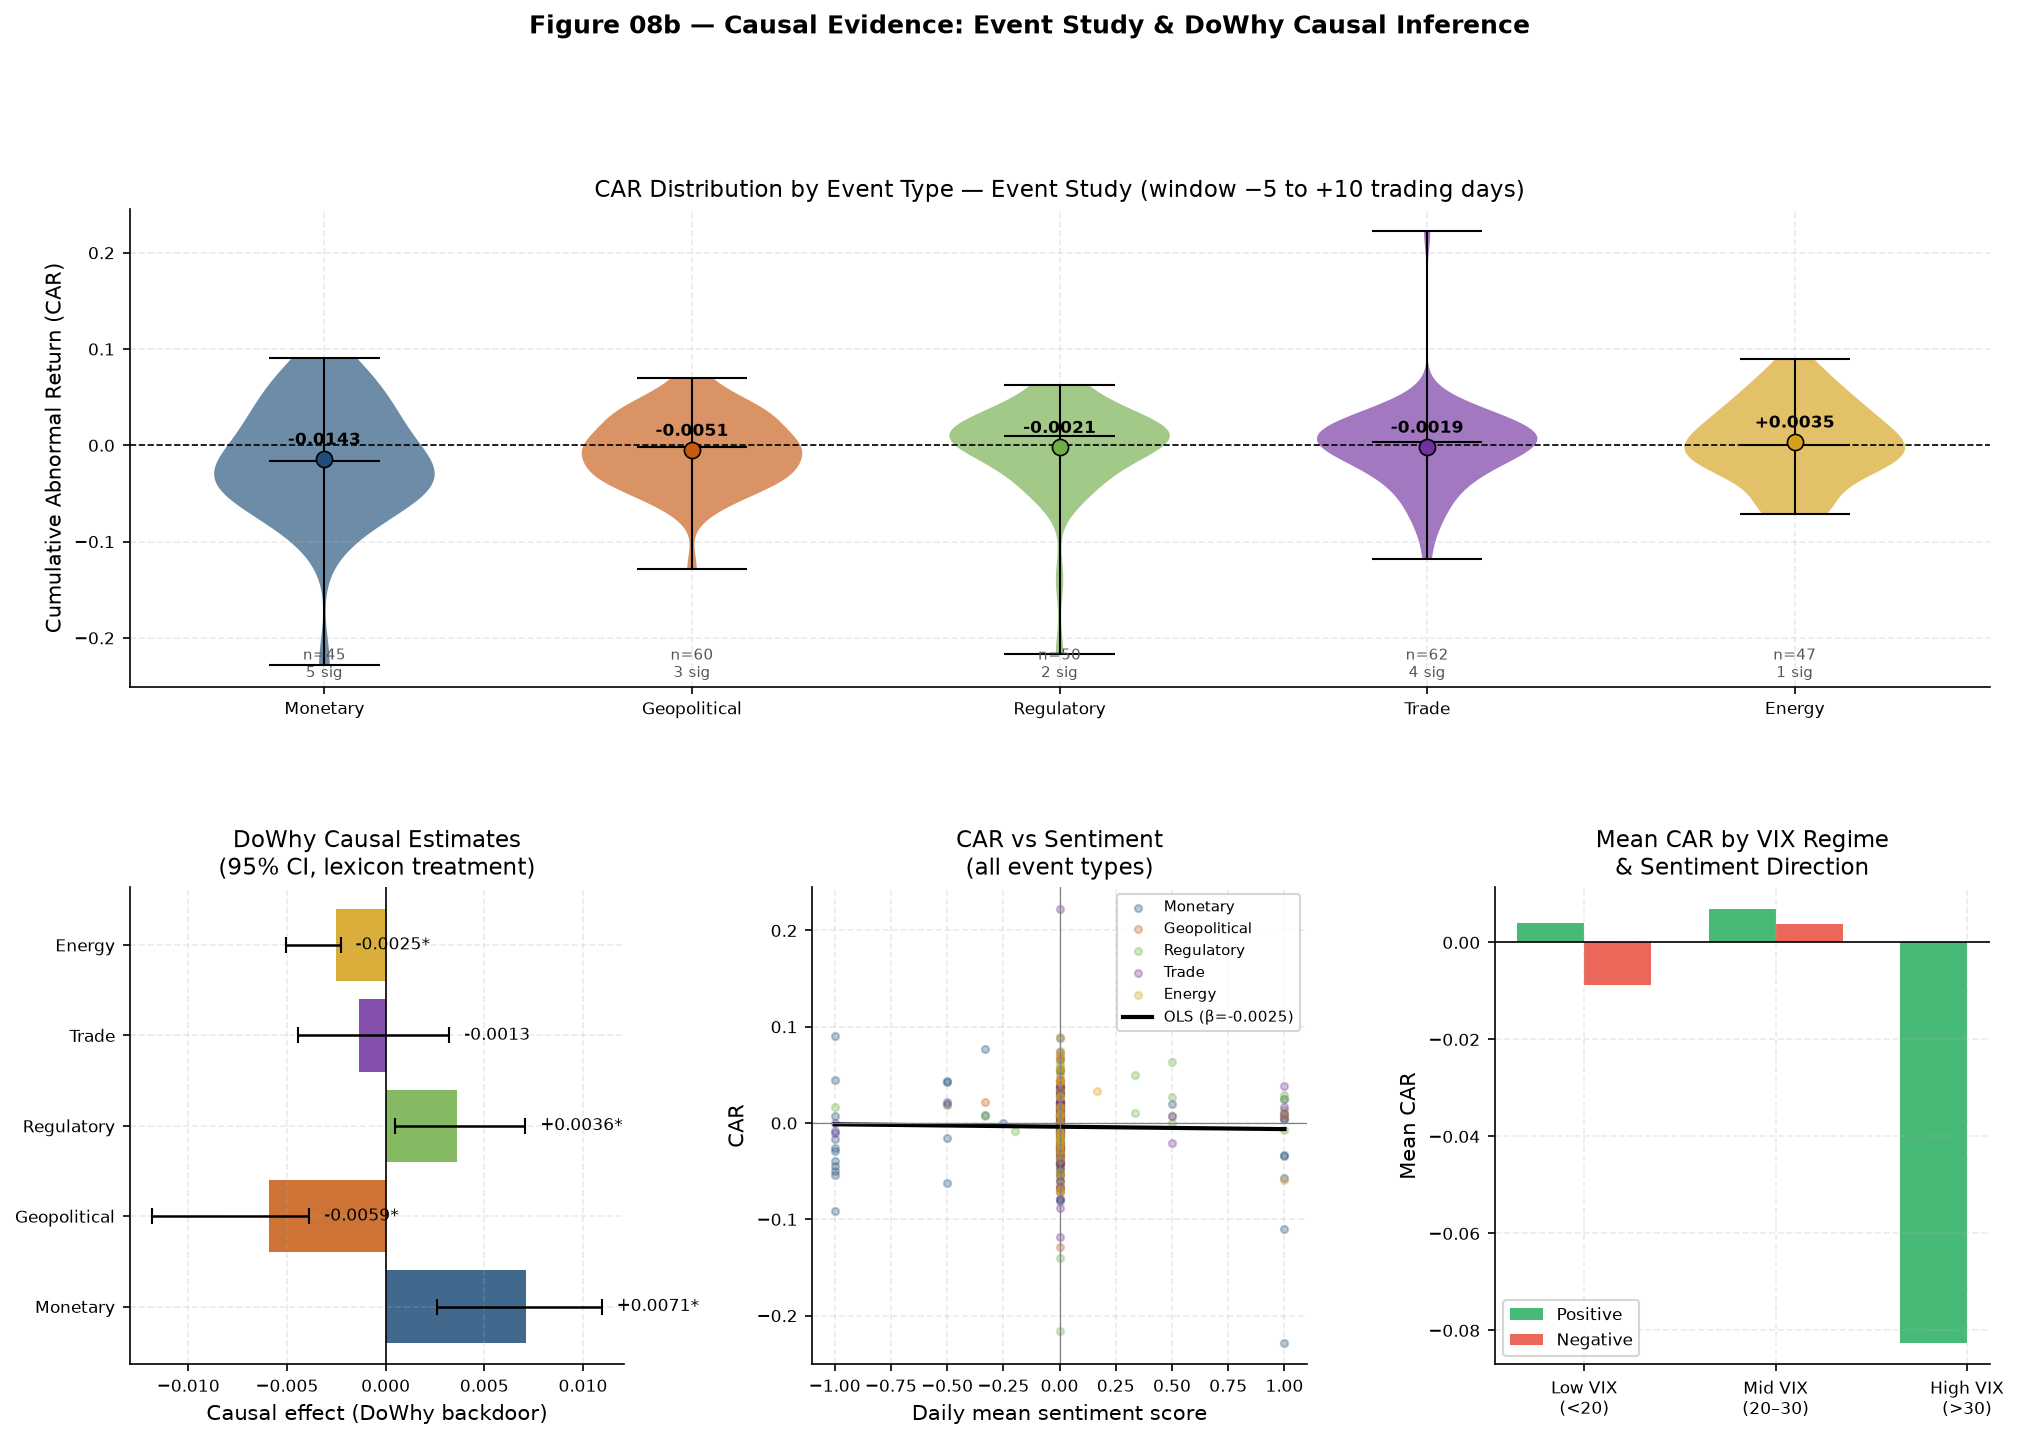

✓ Saved 08b_causal_evidence.png


In [4]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# ── Panel 1: CAR distribution by event type (violin) ─────────────────────────
ax1 = fig.add_subplot(gs[0, :])
car_plot = car_df[car_df['event_type'].isin(EVENT_ORDER)].copy()
car_plot['event_type_label'] = car_plot['event_type'].str.capitalize()
order_labels = [e.capitalize() for e in EVENT_ORDER]

vp = ax1.violinplot(
    [car_plot[car_plot['event_type'] == et]['car'].dropna().values for et in EVENT_ORDER],
    positions=range(len(EVENT_ORDER)),
    showmedians=True, showextrema=True, widths=0.6
)
for pc, et in zip(vp['bodies'], EVENT_ORDER):
    pc.set_facecolor(C[et])
    pc.set_alpha(0.65)
for part in ['cmedians','cmaxes','cmins','cbars']:
    vp[part].set_color('black')
    vp[part].set_linewidth(1)

# Mean CAR dots
for i, et in enumerate(EVENT_ORDER):
    grp = car_plot[car_plot['event_type'] == et]['car'].dropna()
    mean_car = grp.mean()
    ax1.scatter(i, mean_car, s=60, color=C[et], zorder=5, edgecolors='black', linewidths=0.8)
    ax1.text(i, mean_car + 0.015, f'{mean_car:+.4f}', ha='center', fontsize=8, fontweight='bold')

ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xticks(range(len(EVENT_ORDER)))
ax1.set_xticklabels(order_labels)
ax1.set_ylabel('Cumulative Abnormal Return (CAR)')
ax1.set_title('CAR Distribution by Event Type — Event Study (window −5 to +10 trading days)')

# Significance counts
for i, et in enumerate(EVENT_ORDER):
    grp = car_plot[car_plot['event_type'] == et]
    n_sig = grp['significant'].sum() if 'significant' in grp.columns else 0
    n_tot = len(grp)
    ax1.text(i, ax1.get_ylim()[0] + 0.01,
             f'n={n_tot}\n{n_sig} sig', ha='center', fontsize=7, color='#555555')

# ── Panel 2: DoWhy causal estimates with CI ───────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
lex_est = causal_df[causal_df['sentiment_method'] == 'lexicon'].copy()
lex_est = lex_est.set_index('event_type').reindex(EVENT_ORDER).dropna(subset=['causal_effect'])
y_pos = range(len(lex_est))
ax2.barh(y_pos, lex_est['causal_effect'].values,
         xerr=[
             lex_est['causal_effect'].values - lex_est['ci_lower'].values,
             lex_est['ci_upper'].values - lex_est['causal_effect'].values,
         ],
         color=[C[et] for et in lex_est.index],
         alpha=0.85, capsize=4, error_kw=dict(linewidth=1.2))
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([e.capitalize() for e in lex_est.index])
ax2.set_xlabel('Causal effect (DoWhy backdoor)')
ax2.set_title('DoWhy Causal Estimates\n(95% CI, lexicon treatment)')
for i, (et, row) in enumerate(lex_est.iterrows()):
    sig_marker = '*' if row['ci_lower'] > 0 or row['ci_upper'] < 0 else ''
    ax2.text(row['ci_upper'] + 0.0005, i, f" {row['causal_effect']:+.4f}{sig_marker}",
             va='center', fontsize=8)

# ── Panel 3: CAR vs sentiment scatter ────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
for et in EVENT_ORDER:
    grp = car_df[car_df['event_type'] == et].dropna(subset=['car','overall_mean_sentiment'])
    if len(grp) < 5:
        continue
    ax3.scatter(grp['overall_mean_sentiment'], grp['car'],
                alpha=0.3, s=12, color=C[et], label=et.capitalize())
# OLS line on all events
all_grp = car_df.dropna(subset=['car','overall_mean_sentiment'])
m, b    = np.polyfit(all_grp['overall_mean_sentiment'], all_grp['car'], 1)
x_range = np.linspace(all_grp['overall_mean_sentiment'].min(),
                      all_grp['overall_mean_sentiment'].max(), 100)
ax3.plot(x_range, m * x_range + b, 'k-', linewidth=2, label=f'OLS (β={m:.4f})')
ax3.axhline(0, color='grey', linewidth=0.6)
ax3.axvline(0, color='grey', linewidth=0.6)
ax3.set_xlabel('Daily mean sentiment score')
ax3.set_ylabel('CAR')
ax3.set_title('CAR vs Sentiment\n(all event types)')
ax3.legend(fontsize=7)

# ── Panel 4: CAR by VIX regime & sentiment direction ─────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
car_df['vix_regime_label'] = pd.cut(
    car_df['vix'],
    bins=[0, 20, 30, 100],
    labels=['Low VIX\n(<20)', 'Mid VIX\n(20–30)', 'High VIX\n(>30)']
)
car_df['sent_direction'] = car_df['sentiment_numeric'].apply(
    lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral')
)
regime_sent = (
    car_df[car_df['sent_direction'].isin(['Positive','Negative'])]
    .groupby(['vix_regime_label','sent_direction'])['car']
    .mean().unstack()
)
if not regime_sent.empty:
    x_pos = np.arange(len(regime_sent))
    w = 0.35
    for j, (col, clr) in enumerate([('Positive', C['positive']), ('Negative', C['negative'])]):
        if col in regime_sent.columns:
            bars = ax4.bar(x_pos + j * w, regime_sent[col], w,
                           color=clr, alpha=0.85, label=col)
    ax4.set_xticks(x_pos + w/2)
    ax4.set_xticklabels(regime_sent.index)
    ax4.axhline(0, color='black', linewidth=0.8)
    ax4.set_ylabel('Mean CAR')
    ax4.set_title('Mean CAR by VIX Regime\n& Sentiment Direction')
    ax4.legend(fontsize=8)

plt.suptitle('Figure 08b — Causal Evidence: Event Study & DoWhy Causal Inference',
             fontsize=12, fontweight='bold', y=1.01)
plt.savefig(FIGS / '08b_causal_evidence.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved 08b_causal_evidence.png')

---
## Figure 08c — Predictive Pipeline

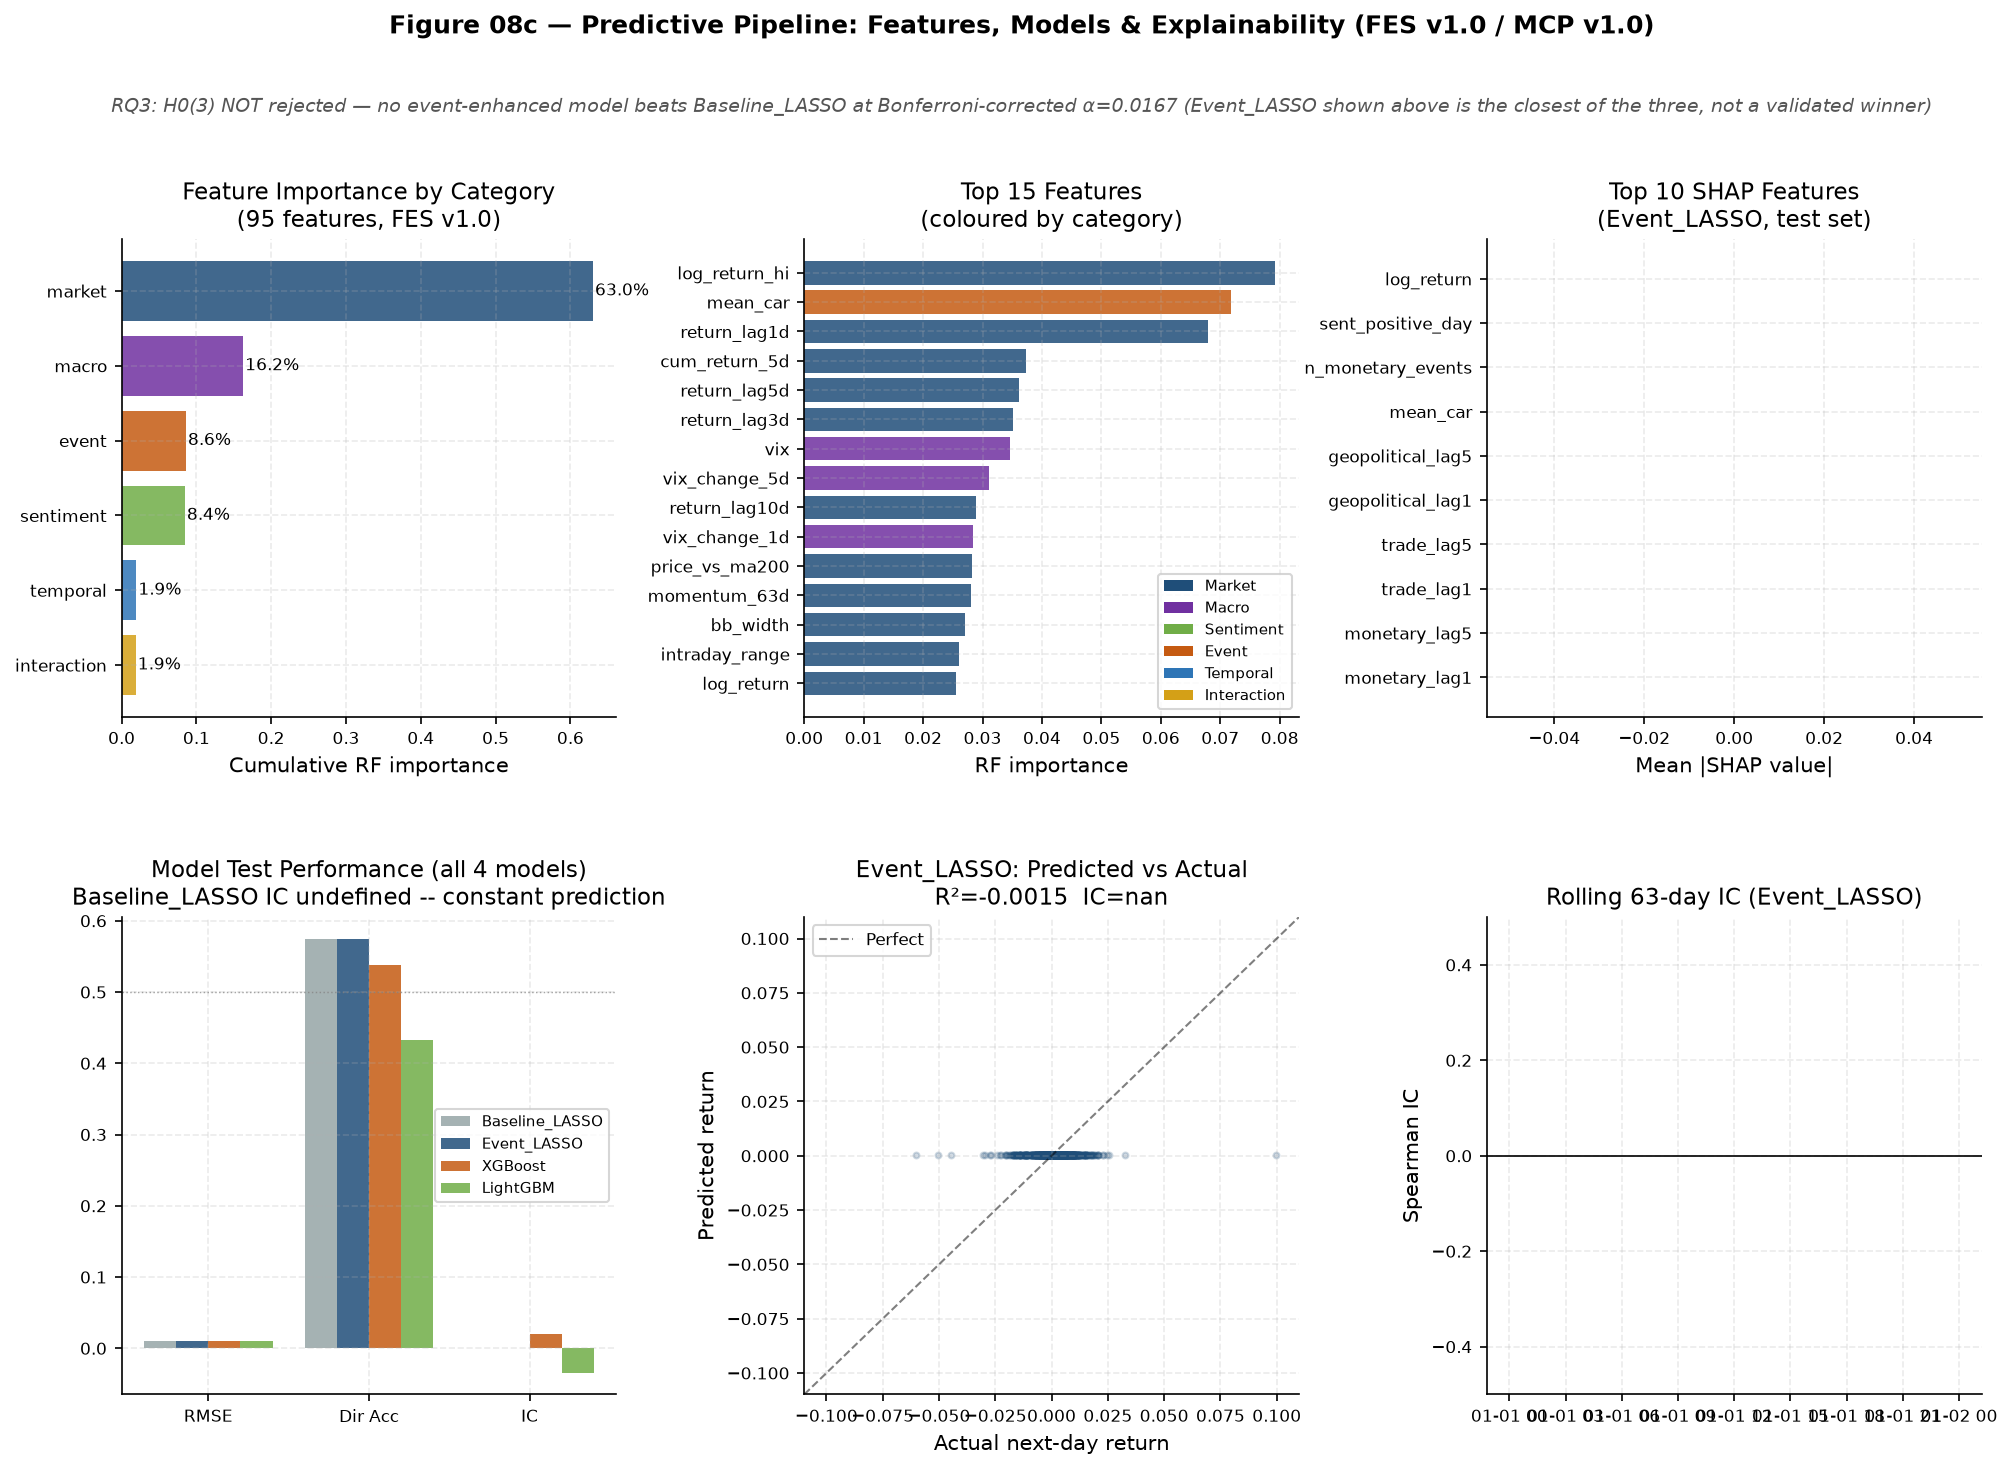

✓ Saved 08c_predictive_pipeline.png (canonical MCP v1.0 pipeline, no legacy inputs)


In [5]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

CATEGORY_COLOURS = {
    'market':      '#1f4e79',
    'macro':       '#7030a0',
    'sentiment':   '#70ad47',
    'event':       '#c55a11',
    'temporal':    '#2e75b6',
    'interaction': '#d4a017',
}
MODEL_COLOURS = {'Baseline_LASSO': '#95a5a6', 'Event_LASSO': C['lasso'], 'XGBoost': C['xgb'], 'LightGBM': C['lgb']}

# ── Panel 1: Feature importance by category (all 95 FES v1.0 features) ───────
ax1 = fig.add_subplot(gs[0, 0])
cat_imp = feat_imp_df.groupby('category')['importance'].sum().sort_values(ascending=False)
bar_colours = [CATEGORY_COLOURS.get(c, '#888') for c in cat_imp.index]
bars = ax1.barh(cat_imp.index[::-1], cat_imp.values[::-1], color=bar_colours[::-1], alpha=0.85)
for bar, val in zip(bars, cat_imp.values[::-1]):
    ax1.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=8)
ax1.set_xlabel('Cumulative RF importance')
ax1.set_title('Feature Importance by Category\n(95 features, FES v1.0)')

# ── Panel 2: Top 15 individual features ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
top15 = feat_imp_df.nlargest(15, 'importance')
feat_colours = [CATEGORY_COLOURS.get(g, '#888') for g in top15['category']]
ax2.barh(top15['feature'][::-1], top15['importance'][::-1],
         color=feat_colours[::-1], alpha=0.85)
ax2.set_xlabel('RF importance')
ax2.set_title('Top 15 Features\n(coloured by category)')
legend_els = [Patch(facecolor=c, label=g.capitalize()) for g, c in CATEGORY_COLOURS.items()
              if g in feat_imp_df['category'].values]
ax2.legend(handles=legend_els, fontsize=7, loc='lower right')

# ── Panel 3: SHAP top 10 (mean |SHAP|) for the representative model ──────────
ax3 = fig.add_subplot(gs[0, 2])
shap_rep = shap_dfs[REPRESENTATIVE_MODEL]
shap_feat_cols = [c for c in shap_rep.columns if c not in ('date', 'split', 'base_value')]
mean_abs_shap = pd.Series(np.abs(shap_rep[shap_feat_cols].values).mean(axis=0),
                          index=shap_feat_cols).sort_values(ascending=False)
top10_shap = mean_abs_shap.head(10)
cat_map = feat_imp_df.set_index('feature')['category'].to_dict()
shap_colours = [CATEGORY_COLOURS.get(cat_map.get(f, ''), '#888') for f in top10_shap.index]
ax3.barh(top10_shap.index[::-1], top10_shap.values[::-1], color=shap_colours[::-1], alpha=0.85)
ax3.set_xlabel('Mean |SHAP value|')
ax3.set_title(f'Top 10 SHAP Features\n({REPRESENTATIVE_MODEL}, test set)')

# ── Panel 4: Model comparison metrics -- all 4 models (incl. Baseline_LASSO) ──
ax4 = fig.add_subplot(gs[1, 0])
test_comp = comp_df[comp_df['Split'] == 'test'].set_index('Model')
model_order = ['Baseline_LASSO', 'Event_LASSO', 'XGBoost', 'LightGBM']
metrics_show  = ['RMSE', 'Dir_Acc', 'IC']
metric_labels = ['RMSE', 'Dir Acc', 'IC']
x = np.arange(len(metrics_show))
w = 0.2
for j, mname in enumerate(model_order):
    if mname in test_comp.index:
        vals = [test_comp.loc[mname, m] if pd.notna(test_comp.loc[mname, m]) else 0 for m in metrics_show]
        ax4.bar(x + j * w, vals, w, color=MODEL_COLOURS[mname], alpha=0.85, label=mname)
ax4.set_xticks(x + 1.5 * w)
ax4.set_xticklabels(metric_labels)
ax4.axhline(0.5, color='grey', linewidth=0.7, linestyle=':', alpha=0.7)
ax4.set_title('Model Test Performance (all 4 models)\nBaseline_LASSO IC undefined -- constant prediction')
ax4.legend(fontsize=7)

# ── Panel 5: Predicted vs actual scatter (representative model) ─────────────
ax5 = fig.add_subplot(gs[1, 1])
lim = max(abs(y_true.min()), abs(y_true.max())) * 1.1
ax5.scatter(y_true, y_rep, alpha=0.2, s=8, color=MODEL_COLOURS[REPRESENTATIVE_MODEL])
ax5.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1, alpha=0.5, label='Perfect')
r2 = r2_score(y_true, y_rep)
ic = pd.Series(y_rep).corr(pd.Series(y_true), method='spearman')
ax5.set_xlim(-lim, lim); ax5.set_ylim(-lim, lim)
ax5.set_xlabel('Actual next-day return')
ax5.set_ylabel('Predicted return')
ax5.set_title(f'{REPRESENTATIVE_MODEL}: Predicted vs Actual\nR²={r2:.4f}  IC={ic:.3f}')
ax5.legend(fontsize=8)

# ── Panel 6: Rolling IC over time (representative model) ────────────────────
ax6 = fig.add_subplot(gs[1, 2])
roll_ic = []
win = 63
for i in range(win, len(y_true)):
    ic_w = pd.Series(y_rep[i-win:i]).corr(pd.Series(y_true[i-win:i]), method='spearman')
    roll_ic.append(ic_w)
roll_ic = np.array(roll_ic)
roll_dates = rep_dates[win:]
ax6.plot(roll_dates, roll_ic, color=MODEL_COLOURS[REPRESENTATIVE_MODEL], linewidth=1.5)
ax6.fill_between(roll_dates, roll_ic, 0, where=roll_ic >= 0, alpha=0.25, color=C['positive'])
ax6.fill_between(roll_dates, roll_ic, 0, where=roll_ic < 0, alpha=0.25, color=C['negative'])
ax6.axhline(0, color='black', linewidth=0.8)
ax6.set_ylabel('Spearman IC')
ax6.set_title(f'Rolling 63-day IC ({REPRESENTATIVE_MODEL})')
ax6.set_ylim(-0.5, 0.5)

plt.suptitle('Figure 08c — Predictive Pipeline: Features, Models & Explainability (FES v1.0 / MCP v1.0)',
             fontsize=12, fontweight='bold', y=1.03)
fig.text(0.5, 0.965,
         f"RQ3: H0(3) NOT rejected — no event-enhanced model beats Baseline_LASSO at Bonferroni-corrected "
         f"\u03b1=0.0167 ({REPRESENTATIVE_MODEL} shown above is the closest of the three, not a validated winner)",
         ha='center', fontsize=9, style='italic', color='#555555')
plt.savefig(FIGS / '08c_predictive_pipeline.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved 08c_predictive_pipeline.png (canonical MCP v1.0 pipeline, no legacy inputs)')

---
## Figure 08d — Full-Period Integrated Dashboard

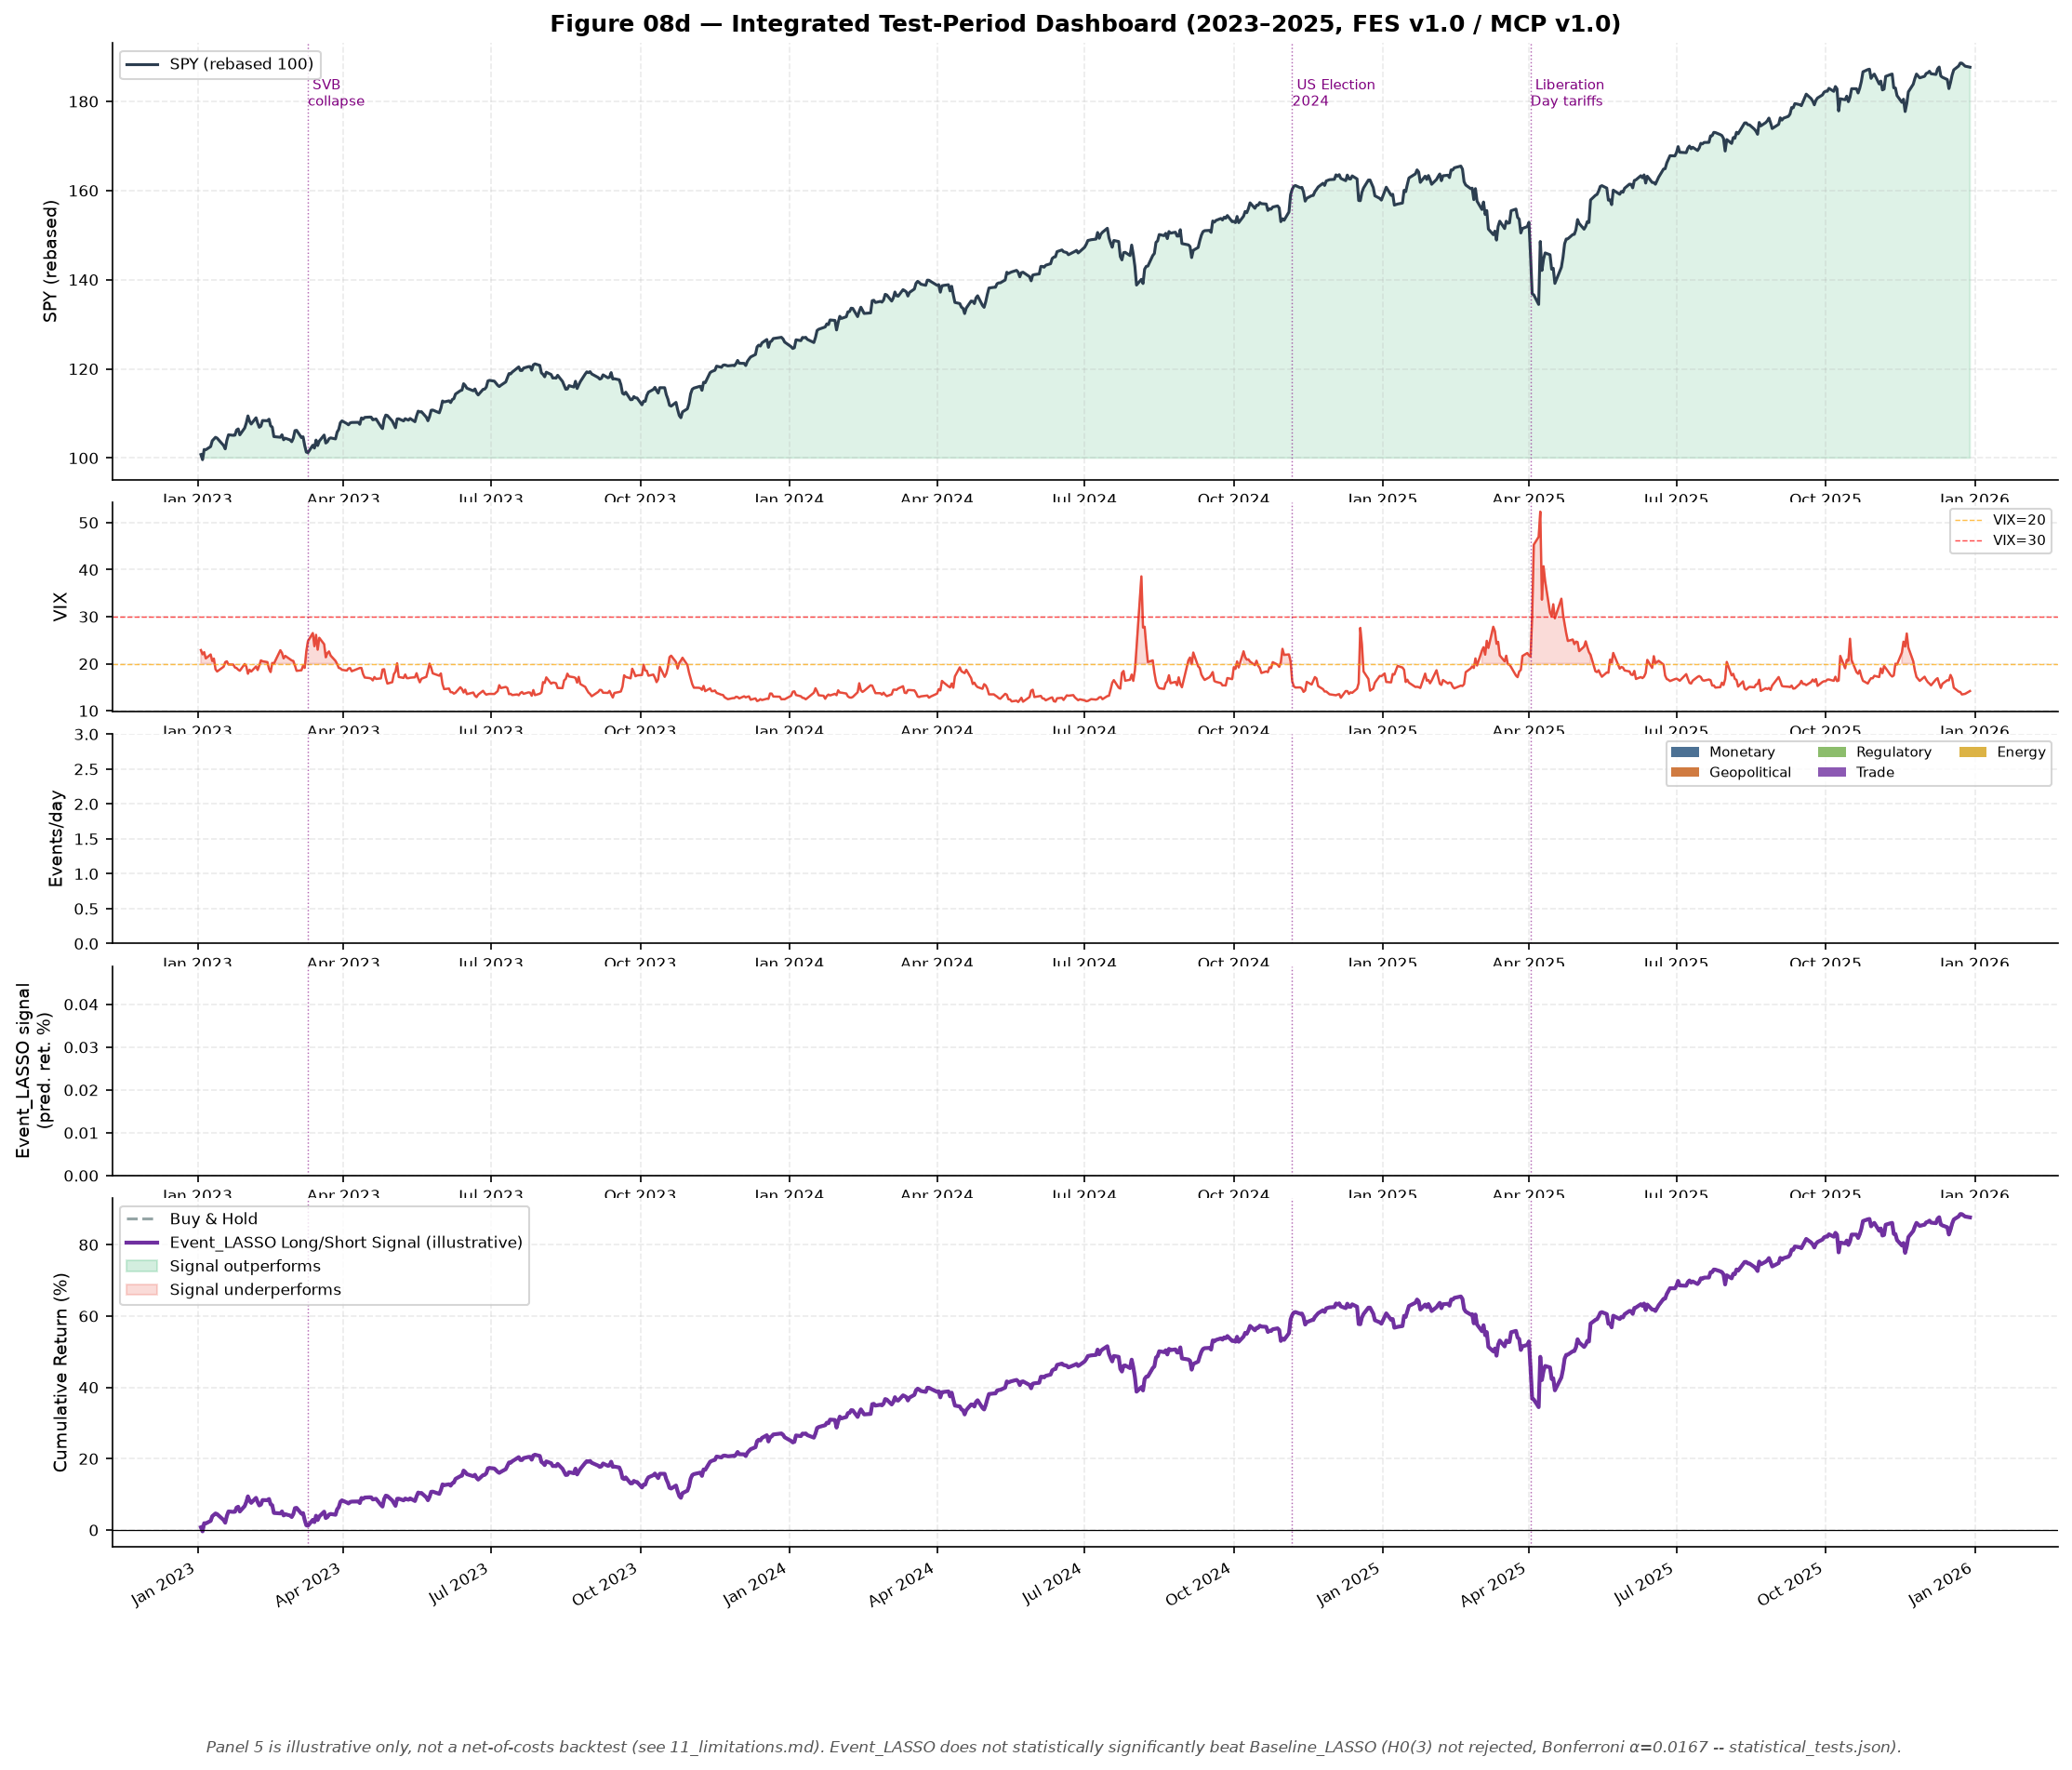

✓ Saved 08d_full_dashboard.png (canonical MCP v1.0 pipeline, no legacy inputs)


In [6]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(5, 1, figure=fig, hspace=0.08, height_ratios=[2.5, 1.2, 1.2, 1.2, 2])

test_dates   = rep_dates
test_feat_df = feat_df[feat_df['date'] > TRAIN_CUT].copy().reset_index(drop=True)

# ── Panel 1: SPY price (reconstructed from actual next-day returns) ──────────
ax1 = fig.add_subplot(gs[0])
spy_price_idx = np.exp(np.cumsum(y_true)) * 100
ax1.plot(test_dates, spy_price_idx, color=C['spy'], linewidth=1.5, label='SPY (rebased 100)')
ax1.fill_between(test_dates, spy_price_idx, 100, where=spy_price_idx >= 100, alpha=0.15, color=C['positive'])
ax1.fill_between(test_dates, spy_price_idx, 100, where=spy_price_idx < 100, alpha=0.15, color=C['negative'])
ax1.set_ylabel('SPY (rebased)', fontsize=9)
ax1.legend(loc='upper left', fontsize=8)
ax1.set_xticklabels([])
ax1.set_title('Figure 08d — Integrated Test-Period Dashboard (2023–2025, FES v1.0 / MCP v1.0)', fontsize=12, fontweight='bold')

# ── Panel 2: VIX ──────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1], sharex=ax1)
vix_ser = test_feat_df.set_index('date')['vix'].reindex(pd.to_datetime(test_dates), method='ffill')
ax2.plot(test_dates, vix_ser.values, color=C['vix'], linewidth=1.2)
ax2.axhline(20, color='orange', linewidth=0.7, linestyle='--', alpha=0.7, label='VIX=20')
ax2.axhline(30, color='red', linewidth=0.7, linestyle='--', alpha=0.7, label='VIX=30')
ax2.fill_between(test_dates, vix_ser.values, 20, where=vix_ser.values > 20, alpha=0.2, color=C['vix'])
ax2.set_ylabel('VIX', fontsize=9)
ax2.legend(loc='upper right', fontsize=7)
ax2.set_xticklabels([])

# ── Panel 3: Daily event volume (stacked by type) ────────────────────────────
ax3 = fig.add_subplot(gs[2], sharex=ax1)
test_events = events_df[
    (events_df['date'] > pd.Timestamp(TRAIN_CUT)) &
    (events_df['event_type'].isin(EVENT_ORDER))
].copy()
daily_evt = (
    test_events.groupby(['date','event_type'])
    .size().unstack(fill_value=0)
    .reindex(columns=EVENT_ORDER, fill_value=0)
)
daily_evt = daily_evt.reindex(pd.to_datetime(test_dates), fill_value=0)
bottom_e = np.zeros(len(test_dates))
for et in EVENT_ORDER:
    if et in daily_evt.columns:
        ax3.bar(test_dates, daily_evt[et].values, bottom=bottom_e,
                color=C[et], alpha=0.8, width=1, label=et.capitalize())
        bottom_e += daily_evt[et].values
ax3.set_ylabel('Events/day', fontsize=9)
ax3.legend(loc='upper right', fontsize=7, ncol=3)
ax3.set_xticklabels([])

# ── Panel 4: Model signal (representative model's predicted return) ─────────
ax4 = fig.add_subplot(gs[3], sharex=ax1)
ax4.bar(test_dates, y_rep * 100,
        color=[C['positive'] if v >= 0 else C['negative'] for v in y_rep],
        alpha=0.7, width=1)
ax4.axhline(0, color='black', linewidth=0.6)
ax4.set_ylabel(f'{REPRESENTATIVE_MODEL} signal\n(pred. ret. %)', fontsize=9)
ax4.set_xticklabels([])

# ── Panel 5: Cumulative signal-based return vs buy-and-hold (illustrative) ──
ax5 = fig.add_subplot(gs[4], sharex=ax1)
strategy_daily = np.sign(y_rep) * y_true
cum_strat = (np.exp(np.cumsum(strategy_daily)) - 1) * 100
cum_bh    = (np.exp(np.cumsum(y_true)) - 1) * 100

ax5.plot(test_dates, cum_bh,    color=C['bh'],       linewidth=1.5,
         linestyle='--', label='Buy & Hold')
ax5.plot(test_dates, cum_strat, color=C['strategy'],  linewidth=2,
         label=f'{REPRESENTATIVE_MODEL} Long/Short Signal (illustrative)')
ax5.fill_between(test_dates, cum_strat, cum_bh,
                 where=cum_strat >= cum_bh, alpha=0.2, color=C['positive'],
                 label='Signal outperforms')
ax5.fill_between(test_dates, cum_strat, cum_bh,
                 where=cum_strat < cum_bh, alpha=0.2, color=C['negative'],
                 label='Signal underperforms')
ax5.axhline(0, color='black', linewidth=0.6)
ax5.set_ylabel('Cumulative Return (%)', fontsize=9)
ax5.legend(loc='upper left', fontsize=8)

ax5.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

key_events = [
    (pd.Timestamp('2023-03-10'), 'SVB\ncollapse', ax1),
    (pd.Timestamp('2024-11-06'), 'US Election\n2024', ax1),
    (pd.Timestamp('2025-04-02'), 'Liberation\nDay tariffs', ax1),
]
test_min, test_max = pd.Timestamp(test_dates.min()), pd.Timestamp(test_dates.max())
for ts, label, ax in key_events:
    if test_min <= ts <= test_max:
        for a in [ax1, ax2, ax3, ax4, ax5]:
            a.axvline(ts, color='purple', linewidth=0.7, linestyle=':', alpha=0.6)
        ax1.text(ts, ax1.get_ylim()[1] * 0.96, f' {label}',
                 fontsize=7, color='purple', va='top')

fig.text(0.5, 0.005,
         f"Panel 5 is illustrative only, not a net-of-costs backtest (see 11_limitations.md). "
         f"{REPRESENTATIVE_MODEL} does not statistically significantly beat Baseline_LASSO "
         f"(H0(3) not rejected, Bonferroni \u03b1=0.0167 -- statistical_tests.json).",
         ha='center', fontsize=8, style='italic', color='#555555')
plt.savefig(FIGS / '08d_full_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved 08d_full_dashboard.png (canonical MCP v1.0 pipeline, no legacy inputs)')

---
## Section 5 — Summary & Figure Index

In [7]:
print('=' * 65)
print('PHASE 8 — RESULTS VISUALISATION: COMPLETE')
print('=' * 65)

print('\nPUBLICATION FIGURES (300 dpi) → reports/figures/')
figures = [
    ('08a_event_landscape.png',    'Event Landscape',     'Event volume, type mix, sentiment & president breakdown'),
    ('08b_causal_evidence.png',    'Causal Evidence',     'CAR violin, DoWhy CI, sentiment scatter, VIX regime'),
    ('08c_predictive_pipeline.png','Predictive Pipeline', 'Feature groups, top features, SHAP, model comparison'),
    ('08d_full_dashboard.png',     'Full Dashboard',      'SPY + VIX + events + signal + strategy (2023–2025)'),
]
for fname, title, desc in figures:
    path = FIGS / fname
    size = f'{path.stat().st_size / 1024:.0f} KB' if path.exists() else 'MISSING'
    print(f'  {fname:<38} [{size:>8}]  {desc}')

print('\nCOMPLETE FIGURE INVENTORY (all phases):')
all_figs = sorted(FIGS.glob('0*.png'))
for p in all_figs:
    print(f'  {p.name}')

print(f'\nPROJECT STATUS:')
phases = [
    ('01', 'Data Collection',      '✅'),
    ('02', 'EDA',                  '✅'),
    ('03', 'Event Detection',      '✅'),
    ('04', 'Causal Analysis',      '✅'),
    ('05', 'Feature Engineering',  '✅'),
    ('06', 'Model Training',       '✅'),
    ('07', 'Model Evaluation',     '✅'),
    ('08', 'Results Visualisation','✅'),
]
for num, name, status in phases:
    print(f'  Phase {num}: {name:<25} {status}')


PHASE 8 — RESULTS VISUALISATION: COMPLETE

PUBLICATION FIGURES (300 dpi) → reports/figures/
  08a_event_landscape.png                [  591 KB]  Event volume, type mix, sentiment & president breakdown
  08b_causal_evidence.png                [  475 KB]  CAR violin, DoWhy CI, sentiment scatter, VIX regime
  08c_predictive_pipeline.png            [  578 KB]  Feature groups, top features, SHAP, model comparison
  08d_full_dashboard.png                 [  818 KB]  SPY + VIX + events + signal + strategy (2023–2025)

COMPLETE FIGURE INVENTORY (all phases):
  01_spy_rebased_price.png
  02b_return_distribution.png
  02c_vix_and_macro.png
  02g_app_doc_distribution.png
  02i_docs_vs_returns.png
  02j_fomc_distribution.png
  02m_descriptive_distributions.png
  02n_qq_plots.png
  02p_rolling_stationarity.png
  02q_acf_pacf.png
  02r_correlation_heatmap.png
  03a_sentiment_distribution.png
  03b_sentiment_timeline.png
  03c_high_impact_events.png
  03d_sentiment_by_event_type.png
  04a_car_by_even

## Handoff Note — End of Pipeline

This is the final notebook in the pipeline (`Dissertation` follows). All four figures (`08a`–`08d`) are current and dissertation-ready, sourced exclusively from frozen, MCP v1.0-verified artefacts. `08c`/`08d` were rebuilt 2026-07-06 (Results Visualisation Freeze, RVF v1.0) to read `feature_matrix.parquet` and `reports/model_comparison/`/`reports/baseline/` instead of the legacy `data/processed/model_features.parquet`/`model_comparison.parquet`. See `10_decision_log.md` (2026-07-06 entries) for the full rebuild rationale and statistical-consistency verification.

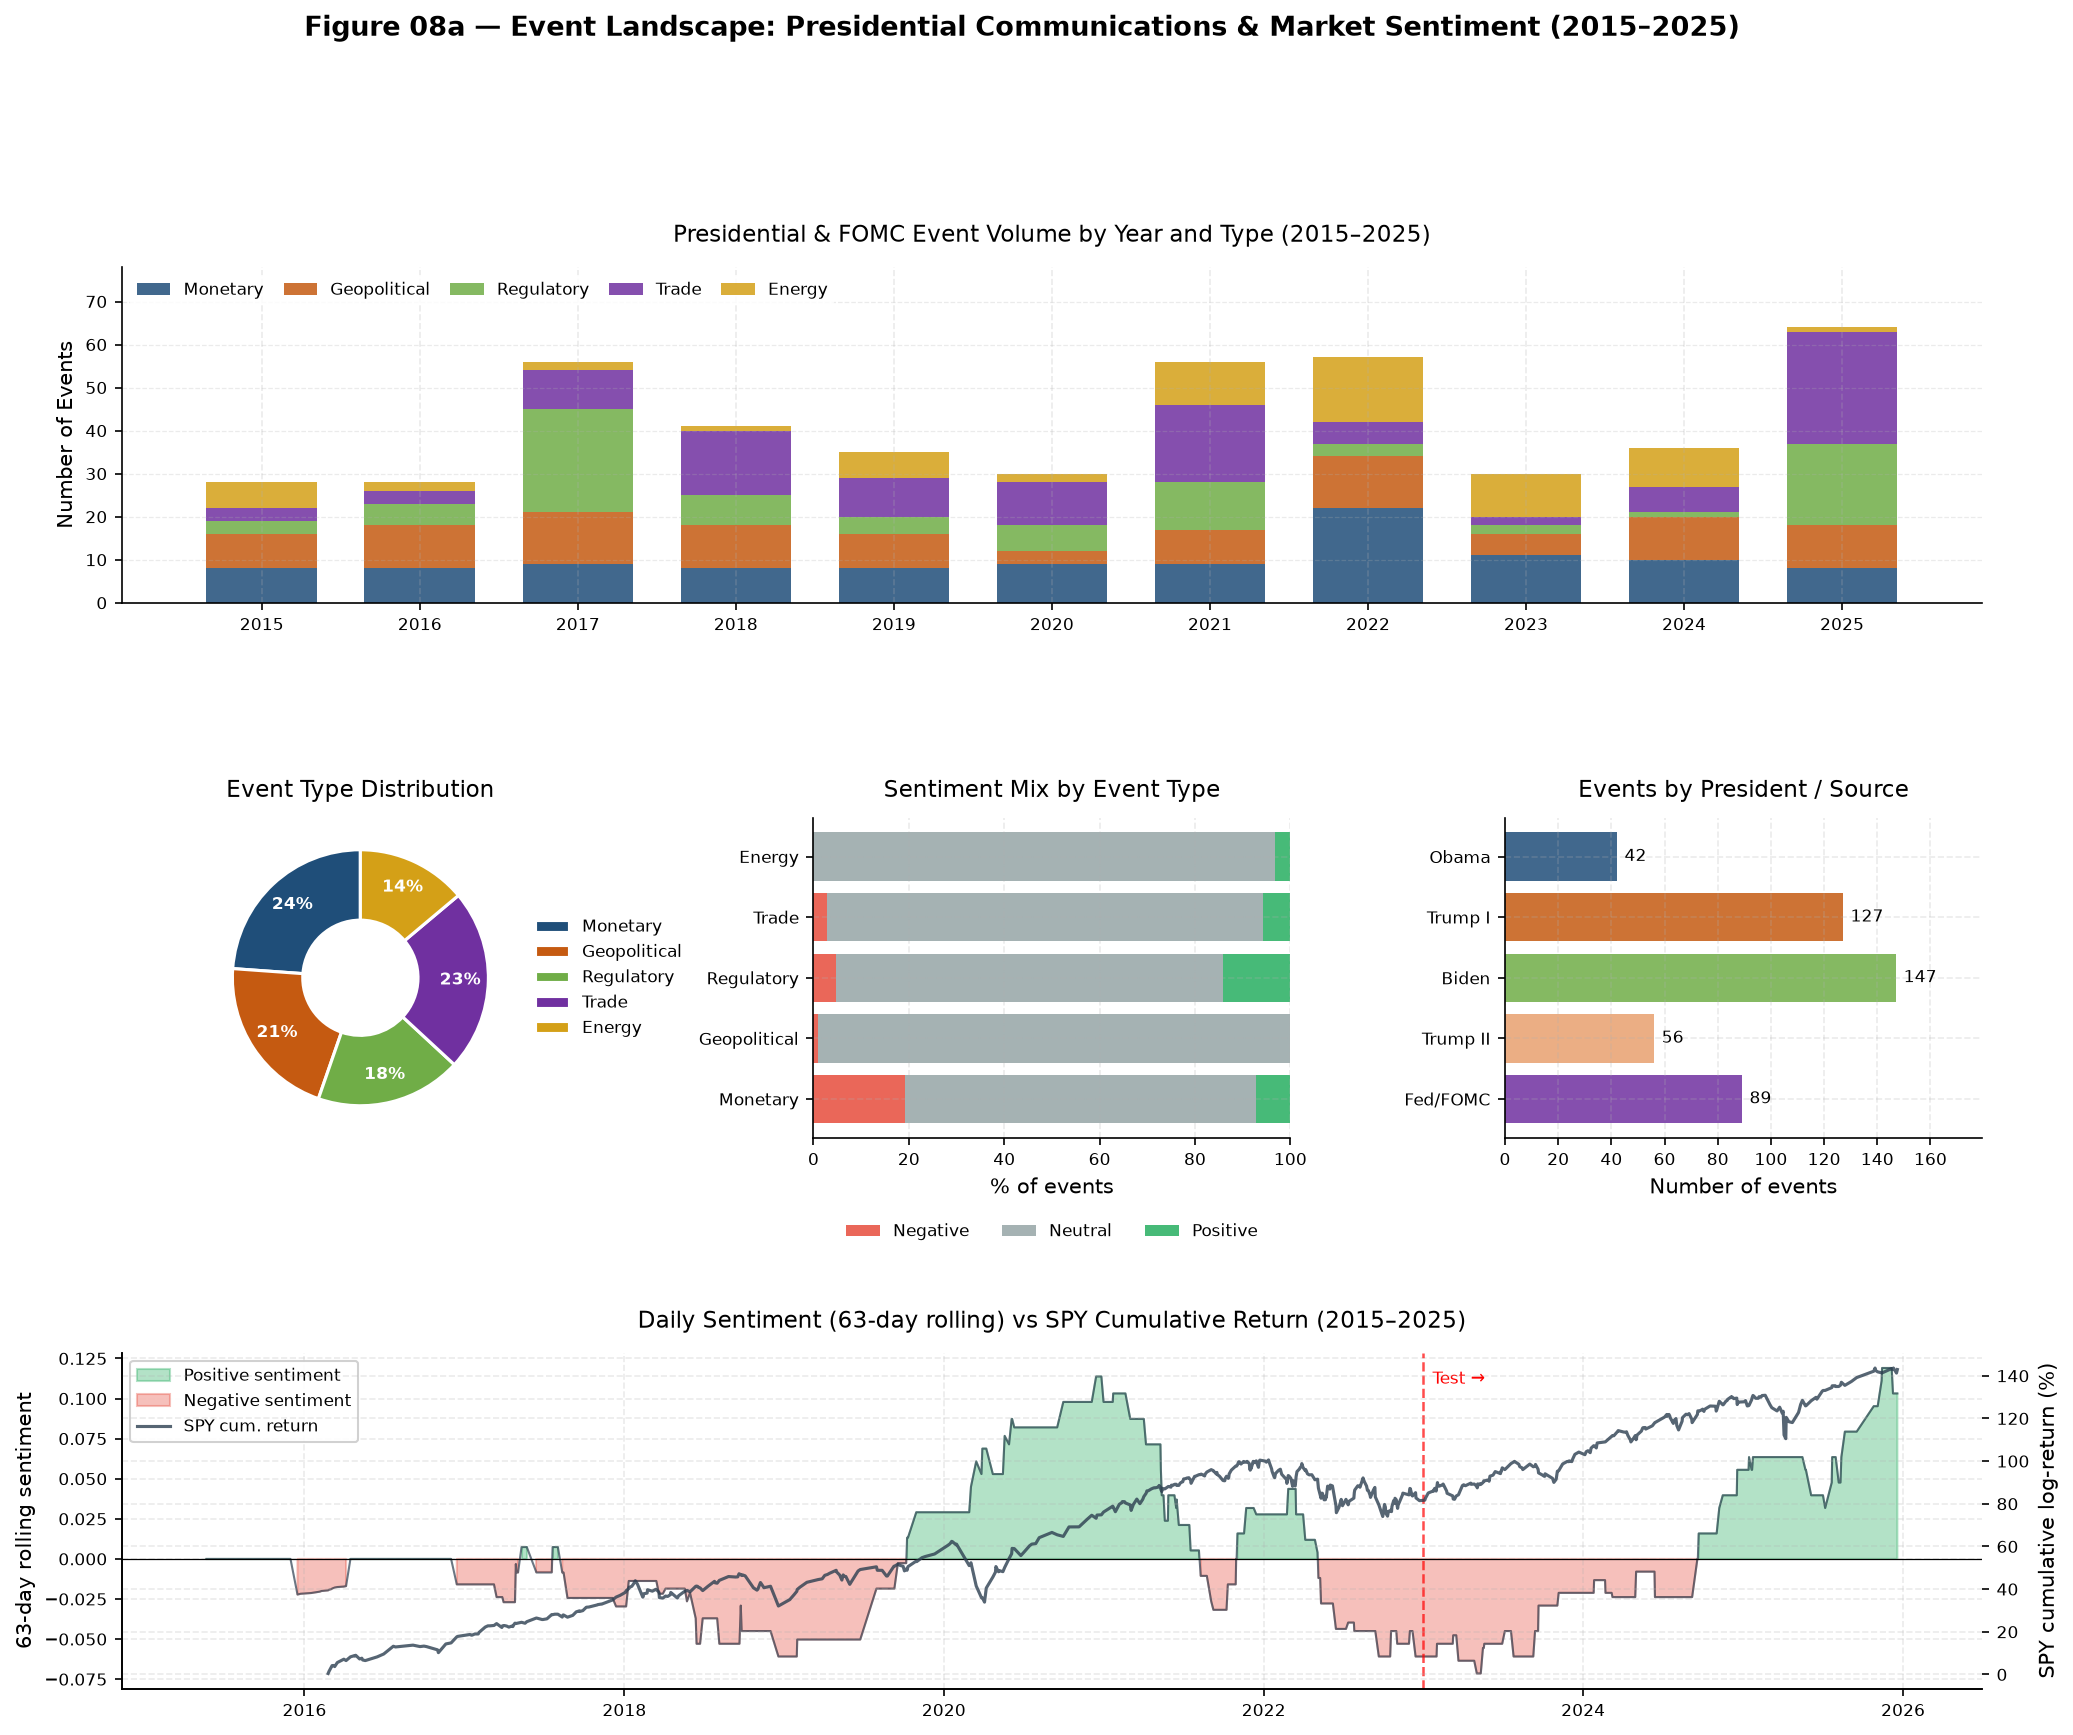

✓ Saved 08a_event_landscape.png


In [8]:
"""
Figure 08a — Event Landscape (revised layout)
Drop-in replacement for the original plotting block.
All upstream variables are assumed already defined in your session:
    events_df, sent_df, feat_df, C, EVENT_ORDER, TRAIN_CUT, FIGS
"""

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(
    3, 3, figure=fig,
    hspace=0.65, wspace=0.45,
    height_ratios=[1.05, 1, 1.05],
)

# ── Panel 1 (top, full width): Event volume over time by type ─────────────────
ax1 = fig.add_subplot(gs[0, :])
yearly = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    .assign(year=events_df['date'].dt.year)
    .groupby(['year', 'event_type'])
    .size().unstack(fill_value=0)
)
yearly = yearly.reindex(columns=[e for e in EVENT_ORDER if e in yearly.columns])
bottom = np.zeros(len(yearly))
for col in yearly.columns:
    ax1.bar(yearly.index, yearly[col], bottom=bottom,
            color=C[col], alpha=0.85, label=col.capitalize(), width=0.7)
    bottom += yearly[col].values
ax1.set_ylabel('Number of Events')
ax1.set_title('Presidential & FOMC Event Volume by Year and Type (2015\u20132025)', pad=12)
# FIX: legend kept inside the axes (not above it), so it never competes with
# the title for vertical space. Extra headroom via margins(y=0.22) plus a
# semi-opaque background keeps it legible against the tallest bars (2021, 2024).
ax1.margins(y=0.22)
ax1.legend(loc='upper left', ncol=5, fontsize=8,
           frameon=True, framealpha=0.85, edgecolor='none', columnspacing=1.2)
ax1.set_xticks(yearly.index)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.25, linewidth=0.6)

# ── Panel 2 (mid-left): Event type distribution (donut) ──────────────────────
ax2 = fig.add_subplot(gs[1, 0])
type_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    ['event_type'].value_counts().reindex(EVENT_ORDER).fillna(0)
)
# FIX: drop inline category labels (they collided on small wedges) and use a
# side legend instead; keep percentage labels inside the wedges only.
wedges, _, autotexts = ax2.pie(
    type_counts.values,
    labels=None,
    colors=[C[t] for t in type_counts.index],
    autopct=lambda p: f'{p:.0f}%' if p >= 4 else '',   # suppress label clutter on tiny wedges
    startangle=90,
    pctdistance=0.78, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5),
)
for at in autotexts:
    at.set_fontsize(8)
    at.set_color('white')
    at.set_fontweight('bold')
ax2.set_title('Event Type Distribution', pad=10)
ax2.legend(wedges, [t.capitalize() for t in type_counts.index],
           loc='center left', bbox_to_anchor=(1.0, 0.5),
           fontsize=8, frameon=False)

# ── Panel 3 (mid-centre): Sentiment distribution by event type ───────────────
ax3 = fig.add_subplot(gs[1, 1])
sent_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    .groupby(['event_type', 'sentiment_label'])
    .size().unstack(fill_value=0)
)
sent_counts = sent_counts.reindex(index=EVENT_ORDER)
sent_pct = sent_counts.div(sent_counts.sum(axis=1), axis=0) * 100
bottom_s = np.zeros(len(sent_pct))
for sent_label, col in [('negative', C['negative']), ('neutral', C['neutral']), ('positive', C['positive'])]:
    if sent_label in sent_pct.columns:
        ax3.barh([e.capitalize() for e in sent_pct.index],
                 sent_pct[sent_label], left=bottom_s,
                 color=col, alpha=0.85, label=sent_label.capitalize())
        bottom_s += sent_pct[sent_label].values
ax3.set_xlabel('% of events')
ax3.set_title('Sentiment Mix by Event Type', pad=10)
# FIX: legend relocated below the axis, horizontal, so it never overlaps the bars
ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22),
           ncol=3, fontsize=8, frameon=False)
ax3.set_xlim(0, 100)
ax3.spines[['top', 'right']].set_visible(False)

# ── Panel 4 (mid-right): Events by president ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
pres_short = {
    'Barack Obama': 'Obama',
    'Donald J. Trump (1st Term)': 'Trump I',
    'Joseph R. Biden, Jr.': 'Biden',
    'Donald J. Trump (2nd Term)': 'Trump II',
    'Federal Reserve': 'Fed/FOMC',
}
pres_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    ['president'].map(pres_short).value_counts()
)
pres_order = ['Obama', 'Trump I', 'Biden', 'Trump II', 'Fed/FOMC']
pres_counts = pres_counts.reindex([p for p in pres_order if p in pres_counts.index])
# FIX: Trump I / Trump II now get distinguishable shades instead of an identical orange
PALETTE_PRES = {
    'Obama': '#1f4e79',
    'Trump I': '#c55a11',
    'Biden': '#70ad47',
    'Trump II': '#e8a06e',
    'Fed/FOMC': '#7030a0',
}
colors = [PALETTE_PRES[p] for p in pres_counts.index][::-1]
ax4.barh(pres_counts.index[::-1], pres_counts.values[::-1],
         color=colors, alpha=0.85)
# FIX: extend xlim so value labels never crowd/clip the right edge
ax4.set_xlim(0, pres_counts.values.max() * 1.22)
for i, val in enumerate(pres_counts.values[::-1]):
    ax4.text(val + pres_counts.values.max() * 0.02, i, f'{val:,}',
             va='center', fontsize=8)
ax4.set_xlabel('Number of events')
ax4.set_title('Events by President / Source', pad=10)
ax4.spines[['top', 'right']].set_visible(False)

# ── Panel 5 (bottom, full width): Rolling daily sentiment vs SPY ─────────────
ax5 = fig.add_subplot(gs[2, :])
# FIX: dropna instead of fillna(0) — zero-filling missing days created a false
# trough at the start of the series before rolling was applied
daily_overall = sent_df.set_index('date')['overall_mean_sentiment'].dropna()
rolling_sent = daily_overall.rolling(63, min_periods=20).mean()

spy_ret = feat_df.set_index('date')['log_return']
spy_cum = (spy_ret.cumsum() * 100).reindex(rolling_sent.index, method='ffill')

ax5b = ax5.twinx()
ax5.fill_between(rolling_sent.index, rolling_sent, 0,
                 where=rolling_sent >= 0, alpha=0.35, color=C['positive'], label='Positive sentiment')
ax5.fill_between(rolling_sent.index, rolling_sent, 0,
                 where=rolling_sent < 0, alpha=0.35, color=C['negative'], label='Negative sentiment')
ax5.plot(rolling_sent.index, rolling_sent, linewidth=1, color='#2c3e50', alpha=0.7)
ax5b.plot(spy_cum.index, spy_cum.values, color=C['spy'], linewidth=1.5, alpha=0.8, label='SPY cum. return')
ax5.set_ylabel('63-day rolling sentiment')
ax5b.set_ylabel('SPY cumulative log-return (%)')
ax5.set_title('Daily Sentiment (63-day rolling) vs SPY Cumulative Return (2015\u20132025)', pad=12)
lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5b.get_legend_handles_labels()
# FIX: legend given a solid backing so it stays legible over the shaded fill
ax5.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
           fontsize=8, framealpha=0.9)
ax5.axhline(0, color='black', linewidth=0.6)
ax5.axvline(pd.Timestamp(TRAIN_CUT), color='red', linewidth=1.2,
            linestyle='--', alpha=0.7)
ax5.text(pd.Timestamp(TRAIN_CUT), ax5.get_ylim()[1] * 0.85, '  Test \u2192',
         color='red', fontsize=8)
ax5.spines[['top', 'right']].set_visible(False)

# FIX: suptitle pushed further above panel 1, and top margin reserved explicitly
# so the figure-level title never crowds the first subplot title
plt.suptitle('Figure 08a \u2014 Event Landscape: Presidential Communications & Market Sentiment (2015\u20132025)',
             fontsize=13, fontweight='bold', y=1.04)
plt.subplots_adjust(top=0.90)
plt.savefig(FIGS / '08a_event_landscape.png', dpi=300, bbox_inches='tight')
plt.show()
print('\u2713 Saved 08a_event_landscape.png')

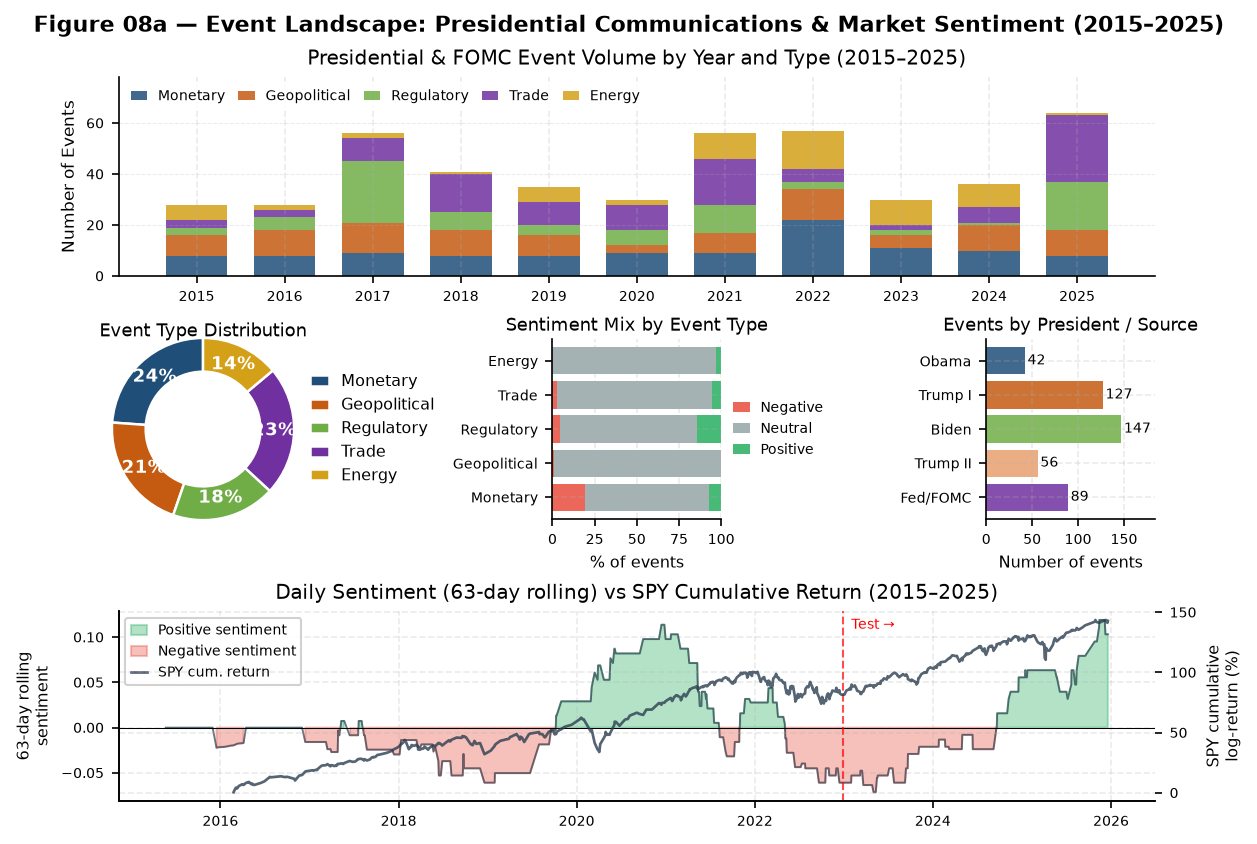

✓ Saved 08a_event_landscape.png at 21cm x 14cm (8.27in x 5.51in)


In [9]:
"""
Figure 08a — Event Landscape, sized to an exact 21 cm x 14 cm canvas.
Same panel layout/legend placement as the version you liked — only sizing,
font scale, and spacing were retuned to fit the smaller physical dimensions.

All upstream variables assumed already defined:
    events_df, sent_df, feat_df, C, EVENT_ORDER, TRAIN_CUT, FIGS
"""

# ── Exact physical size ───────────────────────────────────────────────────
CM_TO_IN = 1 / 2.54
FIG_W_CM, FIG_H_CM = 21, 14
fig = plt.figure(figsize=(FIG_W_CM * CM_TO_IN, FIG_H_CM * CM_TO_IN), constrained_layout=True)

gs = gridspec.GridSpec(
    3, 3, figure=fig,
    height_ratios=[1.05, 0.95, 1.0],
)

# ── Panel 1 (top, full width): Event volume over time by type ─────────────────
ax1 = fig.add_subplot(gs[0, :])
yearly = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    .assign(year=events_df['date'].dt.year)
    .groupby(['year', 'event_type'])
    .size().unstack(fill_value=0)
)
yearly = yearly.reindex(columns=[e for e in EVENT_ORDER if e in yearly.columns])
bottom = np.zeros(len(yearly))
for col in yearly.columns:
    ax1.bar(yearly.index, yearly[col], bottom=bottom,
            color=C[col], alpha=0.85, label=col.capitalize(), width=0.7)
    bottom += yearly[col].values
ax1.set_ylabel('Number of Events', fontsize=8)
ax1.set_title('Presidential & FOMC Event Volume by Year and Type (2015\u20132025)', fontsize=9.5, pad=6)
ax1.margins(y=0.22)
ax1.legend(loc='upper left', ncol=5, fontsize=6.5,
           frameon=True, framealpha=0.85, edgecolor='none', columnspacing=1.0, handlelength=1.2)
ax1.set_xticks(yearly.index)
ax1.tick_params(labelsize=6.5)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.25, linewidth=0.5)

# ── Panel 2 (mid-left): Event type distribution (donut) ──────────────────────
ax2 = fig.add_subplot(gs[1, 0])
type_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    ['event_type'].value_counts().reindex(EVENT_ORDER).fillna(0)
)
wedges, _, autotexts = ax2.pie(
    type_counts.values,
    labels=None,
    colors=[C[t] for t in type_counts.index],
    autopct=lambda p: f'{p:.0f}%' if p >= 4 else '',
    startangle=90,
    radius=1.35,                       # larger donut within the same subplot
    pctdistance=0.78, wedgeprops=dict(width=0.5, edgecolor='white', linewidth=1.2),
)
for at in autotexts:
    at.set_fontsize(8.5)                # bumped up from 6.5 for readability
    at.set_color('white')
    at.set_fontweight('bold')
ax2.set_title('Event Type Distribution', fontsize=8.5, pad=4)
ax2.legend(wedges, [t.capitalize() for t in type_counts.index],
           loc='center left', bbox_to_anchor=(1.05, 0.5),
           fontsize=7.5, frameon=False, handlelength=1.2)

# ── Panel 3 (mid-centre): Sentiment distribution by event type ───────────────
ax3 = fig.add_subplot(gs[1, 1])
sent_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    .groupby(['event_type', 'sentiment_label'])
    .size().unstack(fill_value=0)
)
sent_counts = sent_counts.reindex(index=EVENT_ORDER)
sent_pct = sent_counts.div(sent_counts.sum(axis=1), axis=0) * 100
bottom_s = np.zeros(len(sent_pct))
for sent_label, col in [('negative', C['negative']), ('neutral', C['neutral']), ('positive', C['positive'])]:
    if sent_label in sent_pct.columns:
        ax3.barh([e.capitalize() for e in sent_pct.index],
                 sent_pct[sent_label], left=bottom_s,
                 color=col, alpha=0.85, label=sent_label.capitalize())
        bottom_s += sent_pct[sent_label].values
ax3.set_xlabel('% of events', fontsize=7.5)
ax3.set_title('Sentiment Mix by Event Type', fontsize=8.5, pad=4)
# Side legend (matches the donut's placement) instead of below the axis —
# frees up vertical space so this panel's plot area aligns top/bottom with
# the donut (ax2) and president chart (ax4) in the same row.
ax3.legend(loc='center left', bbox_to_anchor=(1.0, 0.5),
           fontsize=6.5, frameon=False, handlelength=1.2)
ax3.set_xlim(0, 100)
ax3.tick_params(labelsize=6.5)
ax3.spines[['top', 'right']].set_visible(False)

# ── Panel 4 (mid-right): Events by president ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
pres_short = {
    'Barack Obama': 'Obama',
    'Donald J. Trump (1st Term)': 'Trump I',
    'Joseph R. Biden, Jr.': 'Biden',
    'Donald J. Trump (2nd Term)': 'Trump II',
    'Federal Reserve': 'Fed/FOMC',
}
pres_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    ['president'].map(pres_short).value_counts()
)
pres_order = ['Obama', 'Trump I', 'Biden', 'Trump II', 'Fed/FOMC']
pres_counts = pres_counts.reindex([p for p in pres_order if p in pres_counts.index])
PALETTE_PRES = {
    'Obama': '#1f4e79',
    'Trump I': '#c55a11',
    'Biden': '#70ad47',
    'Trump II': '#e8a06e',
    'Fed/FOMC': '#7030a0',
}
colors = [PALETTE_PRES[p] for p in pres_counts.index][::-1]
ax4.barh(pres_counts.index[::-1], pres_counts.values[::-1], color=colors, alpha=0.85)
ax4.set_xlim(0, pres_counts.values.max() * 1.25)
for i, val in enumerate(pres_counts.values[::-1]):
    ax4.text(val + pres_counts.values.max() * 0.02, i, f'{val:,}', va='center', fontsize=6.5)
ax4.set_xlabel('Number of events', fontsize=7.5)
ax4.set_title('Events by President / Source', fontsize=8.5, pad=4)
ax4.tick_params(labelsize=6.5)
ax4.spines[['top', 'right']].set_visible(False)

# ── Panel 5 (bottom, full width): Rolling daily sentiment vs SPY ─────────────
ax5 = fig.add_subplot(gs[2, :])
daily_overall = sent_df.set_index('date')['overall_mean_sentiment'].dropna()
rolling_sent = daily_overall.rolling(63, min_periods=20).mean()

spy_ret = feat_df.set_index('date')['log_return']
spy_cum = (spy_ret.cumsum() * 100).reindex(rolling_sent.index, method='ffill')

ax5b = ax5.twinx()
ax5.fill_between(rolling_sent.index, rolling_sent, 0,
                 where=rolling_sent >= 0, alpha=0.35, color=C['positive'], label='Positive sentiment')
ax5.fill_between(rolling_sent.index, rolling_sent, 0,
                 where=rolling_sent < 0, alpha=0.35, color=C['negative'], label='Negative sentiment')
ax5.plot(rolling_sent.index, rolling_sent, linewidth=0.9, color='#2c3e50', alpha=0.7)
ax5b.plot(spy_cum.index, spy_cum.values, color=C['spy'], linewidth=1.3, alpha=0.8, label='SPY cum. return')
ax5.set_ylabel('63-day rolling\nsentiment', fontsize=7.5)
ax5b.set_ylabel('SPY cumulative\nlog-return (%)', fontsize=7.5)
ax5.set_title('Daily Sentiment (63-day rolling) vs SPY Cumulative Return (2015\u20132025)', fontsize=9.5, pad=6)
lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5b.get_legend_handles_labels()
ax5.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=6.5, framealpha=0.9, handlelength=1.2)
ax5.axhline(0, color='black', linewidth=0.5)
ax5.axvline(pd.Timestamp(TRAIN_CUT), color='red', linewidth=1.0, linestyle='--', alpha=0.7)
ax5.text(pd.Timestamp(TRAIN_CUT), ax5.get_ylim()[1] * 0.85, '  Test \u2192', color='red', fontsize=6.5)
ax5.tick_params(labelsize=6.5)
ax5b.tick_params(labelsize=6.5)
ax5.spines[['top', 'right']].set_visible(False)

fig.suptitle('Figure 08a \u2014 Event Landscape: Presidential Communications & Market Sentiment (2015\u20132025)',
             fontsize=10.5, fontweight='bold')

# ── Save at the EXACT canvas size — no bbox_inches='tight' (that crops and
#    silently changes the physical dimensions away from 21cm x 14cm) ─────────
fig.savefig(FIGS / '08a_event_landscape.png', dpi=300)
plt.show()
print(f'\u2713 Saved 08a_event_landscape.png at {FIG_W_CM}cm x {FIG_H_CM}cm '
      f'({fig.get_size_inches()[0]:.2f}in x {fig.get_size_inches()[1]:.2f}in)')